In [1]:
# 引入常用库
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as st
import datetime as dt
import itertools # 迭代器工具
import pickle
from IPython.core.display import HTML
import talib # 技术分析
import tushare as ts
# 画图
import matplotlib.pyplot as plt
import matplotlib.dates as mdate
import seaborn as sns
# 设置字体 用来正常显示中文标签
from matplotlib import rcParams

rcParams['font.family'] = ['stHeiti']

# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False
# 图表主题
plt.style.use('ggplot')

# 忽略报错
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('csi300.csv')
df['trade_date'] = pd.to_datetime(df['trade_date'])
df.set_index('trade_date',inplace = True)
df = df.loc['2005-02-01':'2017-02-18']
df1 = df.loc['2005-01-04':'2017-01-04']
df.head()

,open,high,low,close,volume
trade_date,,,,,
2005-02-01,953.3296,965.4773,952.7410,955.951,7433066.76
2005-02-02,956.7005,1006.9321,956.7005,1006.913,17057338.57
2005-02-03,1005.5625,1014.1873,992.1552,993.215,16974539.33
2005-02-04,992.2495,1021.0252,989.9388,1016.858,15736214.61
2005-02-16,1023.3238,1033.2476,1018.4867,1023.584,12131293.05


In [3]:
# TOKEN = "789696a2bb40aed04a4165edab1d6180d36a83b40259201771581f8f" 
# ts.set_token(TOKEN)
# pro = ts.pro_api()
# df = pro.index_daily(ts_code='000300.SH', start_date='2000001', end_date='20260731')
# df = df.sort_values('trade_date').reset_index(drop=True)
# df['trade_date'] = pd.to_datetime(df['trade_date'])
# df.set_index('trade_date', inplace=True)
# df = df[['open', 'high', 'low', 'close', 'vol']].rename(columns={'vol': 'volume'})

# # 保存到本地，以后直接读
# df.to_csv('csi300.csv')

In [4]:
def cal_fee(datas,signal_name='signal',fee_rate = 0.003):
    df = datas.copy()
    today_signal = df[signal_name]
    yesterday_signal = df[signal_name].shift(1)

    df['fee'] = (today_signal != yesterday_signal) & yesterday_signal.notna()
    df['cost'] = df['fee']*fee_rate
    return df


def risk_table(datas):
    df = datas.copy()
    temp = []
    for i in ['CUM_RET','SUB_CUM_RET']:
        annual_ret = df[i][-1]**(252/len(df[i]))-1

        #总收益率
        total_ret = df[i][-1]-1

        # 最大回撤
        max_nv = df[i].cummax()
        mdd = np.min(df[i]/max_nv-1)

        # 夏普比率
        if i == 'CUM_RET':
            sharpe_ratio = df['RET'].mean()/df['RET'].std()*np.sqrt(252)
        elif i == 'SUB_CUM_RET':
            sharpe_ratio = df['SUB_FEE_RET'].mean()/df['SUB_FEE_RET'].std()*np.sqrt(252)

        temp.append([f'{annual_ret:.2%}',f'{total_ret:.2%}', f'{mdd:.2%}', f'{sharpe_ratio:.2%}'])
    
    return pd.DataFrame(temp, index=['策略', '策略扣双向费率'], columns=['年华收益率', '累计收益', '最大回撤', '夏普'])



In [5]:
def Ma_Strategy(data):
    df = data.copy()
    df['ma20'] = df['close'].rolling(20).mean()
    df['signal'] = (df['close'] > df['ma20']).shift(1).fillna(0).astype(int)
    df['ret'] = df['close'].pct_change().fillna(0)

    df = cal_fee(df)
    df['RET'] = df['ret']*df['signal']
    # 扣除交易费用的收益率
    df['SUB_FEE_RET'] = df['RET']-df['cost']
    # 策略净值
    df['CUM_RET'] = (1+df['RET']).cumprod()
    df['SUB_CUM_RET'] = (1+df['SUB_FEE_RET']).cumprod()

    # 基准净值
    benchmark = (1+df['ret']).cumprod()


        # 画图
    plt.figure()
    fig = plt.figure(figsize=(20, 10))
    ax1 = fig.add_subplot(1, 1, 1)

    ax1.plot(df['CUM_RET'], label='均值策略')
    ax1.plot(df['SUB_CUM_RET'], label='均值策略(扣双边手续费0.6%)')
    ax1.plot(benchmark, label='沪深300')

    ax1.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))
    plt.legend(loc='best')
    plt.xlabel('时间')
    plt.ylabel('净值')
    plt.title('均线策略净值曲线')
    plt.show()

    display(HTML(risk_table(df).to_html()))

    # 成本侵蚀分析
    total_cost = df['cost'].sum()
    trades = df['fee'].sum()
    years = len(df) / 252
    
    print("\n" + "="*50)
    print("           交易成本诊断")
    print("="*50)
    print(f"回测时长: {years:.1f} 年")
    print(f"调仓次数: {trades:.0f} 次 ({trades/years:.1f} 次/年)")
    print(f"总费用: {total_cost:.4f} ({total_cost:.2%})")
    print(f"费前最终净值: {df['CUM_RET'].iloc[-1]:.4f}")
    print(f"费后最终净值: {df['SUB_CUM_RET'].iloc[-1]:.4f}")
    print(f"费用侵蚀幅度: {(1 - df['SUB_CUM_RET'].iloc[-1]/df['CUM_RET'].iloc[-1]):.2%}")
    print("="*50)


def BBANDS_Strategy(data):
    df = data.copy()
    df['ret'] = df['close'].pct_change().fillna(0)

    upper_band,middle_band,lower_band = talib.BBANDS(df['close'].values,timeperiod=14,nbdevup = 2,nbdevdn = 2,matype = 0)
    signal = np.zeros(len(df))
    for i in range(len(df)):
        if df['close'].iloc[i] > upper_band[i]:
            signal[i] = 1
        elif df['close'].iloc[i] < lower_band[i]:
            signal[i] = 0
        else:
            signal[i] = signal[i-1]

    df['signal'] = signal
    df['signal'] = df['signal'].shift(1).fillna(0)
    df = cal_fee(df)

    # 计算持仓收益
    # 滞后一期收益：今日收盘计算信号，次日买入
    df['RET'] = df['ret']*df['signal']

    # 计算扣除双边手续费收益
    df['SUB_FEE_RET'] = df['RET']-df['cost']

    # 策略净值
    df['CUM_RET'] = (1+df['RET']).cumprod()
    df['SUB_CUM_RET'] = (1+df['SUB_FEE_RET']).cumprod()

    # 基准净值
    benchmark = (1+df['ret']).cumprod()

    # 画图
    plt.figure()
    fig = plt.figure(figsize=(20, 10))
    ax1 = fig.add_subplot(1, 1, 1)

    ax1.plot(df['CUM_RET'], label='布林策略')
    ax1.plot(df['SUB_CUM_RET'], label='布林策略(扣双边手续费0.6%)')
    ax1.plot(benchmark, label='沪深300')

    ax1.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))
    plt.legend(loc='best')
    plt.xlabel('时间')
    plt.ylabel('净值')
    plt.title('布林通道策略净值曲线')
    plt.show()

    # 风险报告
    display(HTML(risk_table(df).to_html()))
    
    

<Figure size 640x480 with 0 Axes>

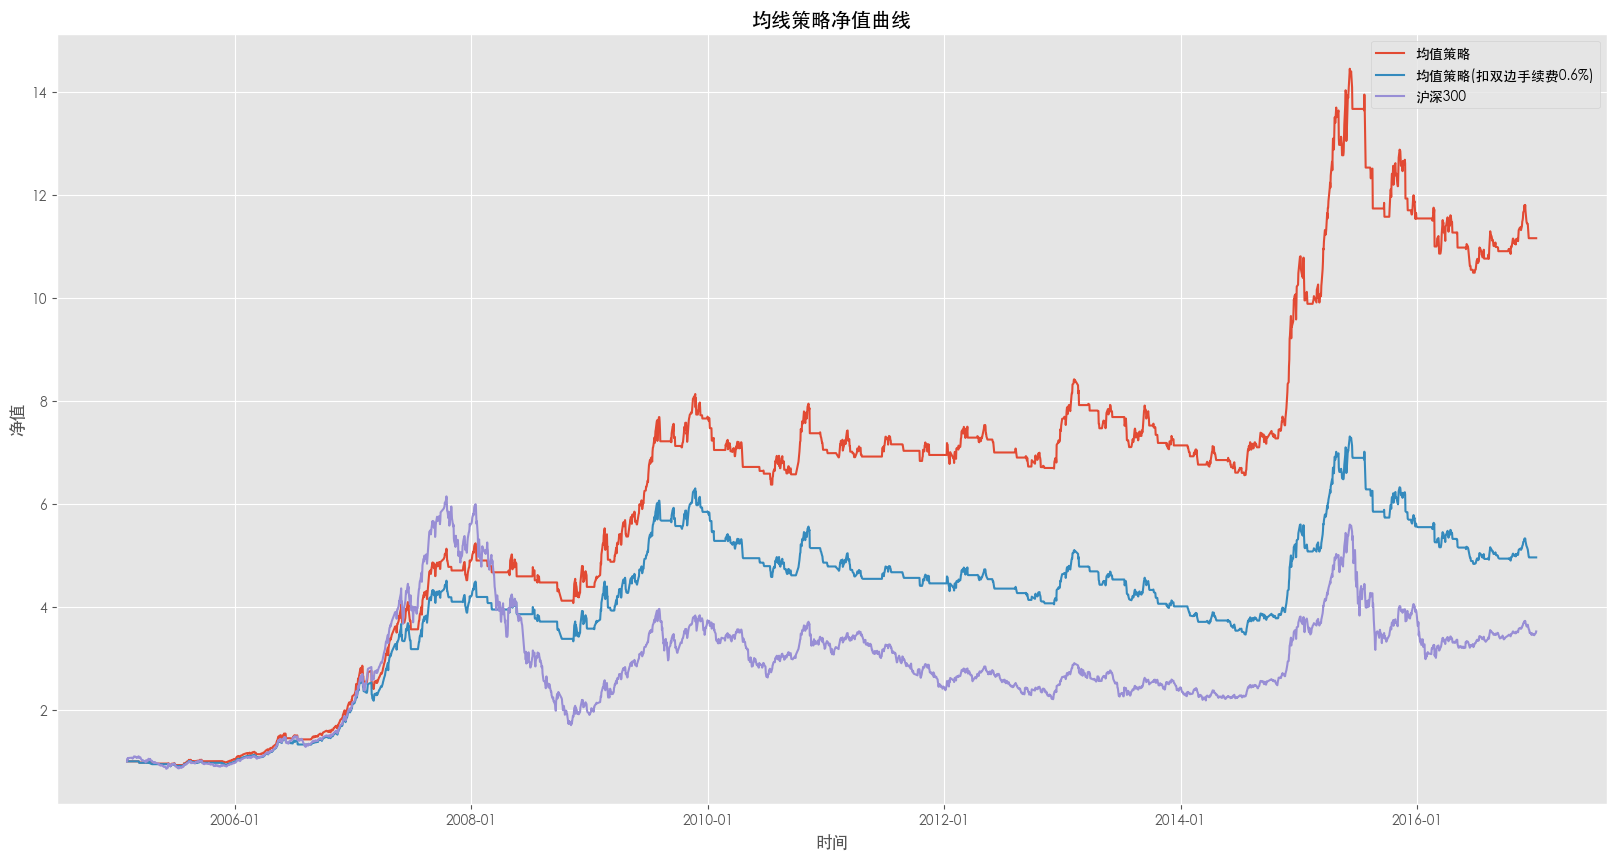

,年华收益率,累计收益,最大回撤,夏普
策略,23.35%,1016.42%,-27.41%,118.93%
策略扣双向费率,14.95%,396.22%,-45.06%,81.99%



           交易成本诊断
回测时长: 11.5 年
调仓次数: 270 次 (23.5 次/年)
总费用: 0.8100 (81.00%)
费前最终净值: 11.1642
费后最终净值: 4.9622
费用侵蚀幅度: 55.55%


In [6]:
Ma_Strategy(df1)

<Figure size 640x480 with 0 Axes>

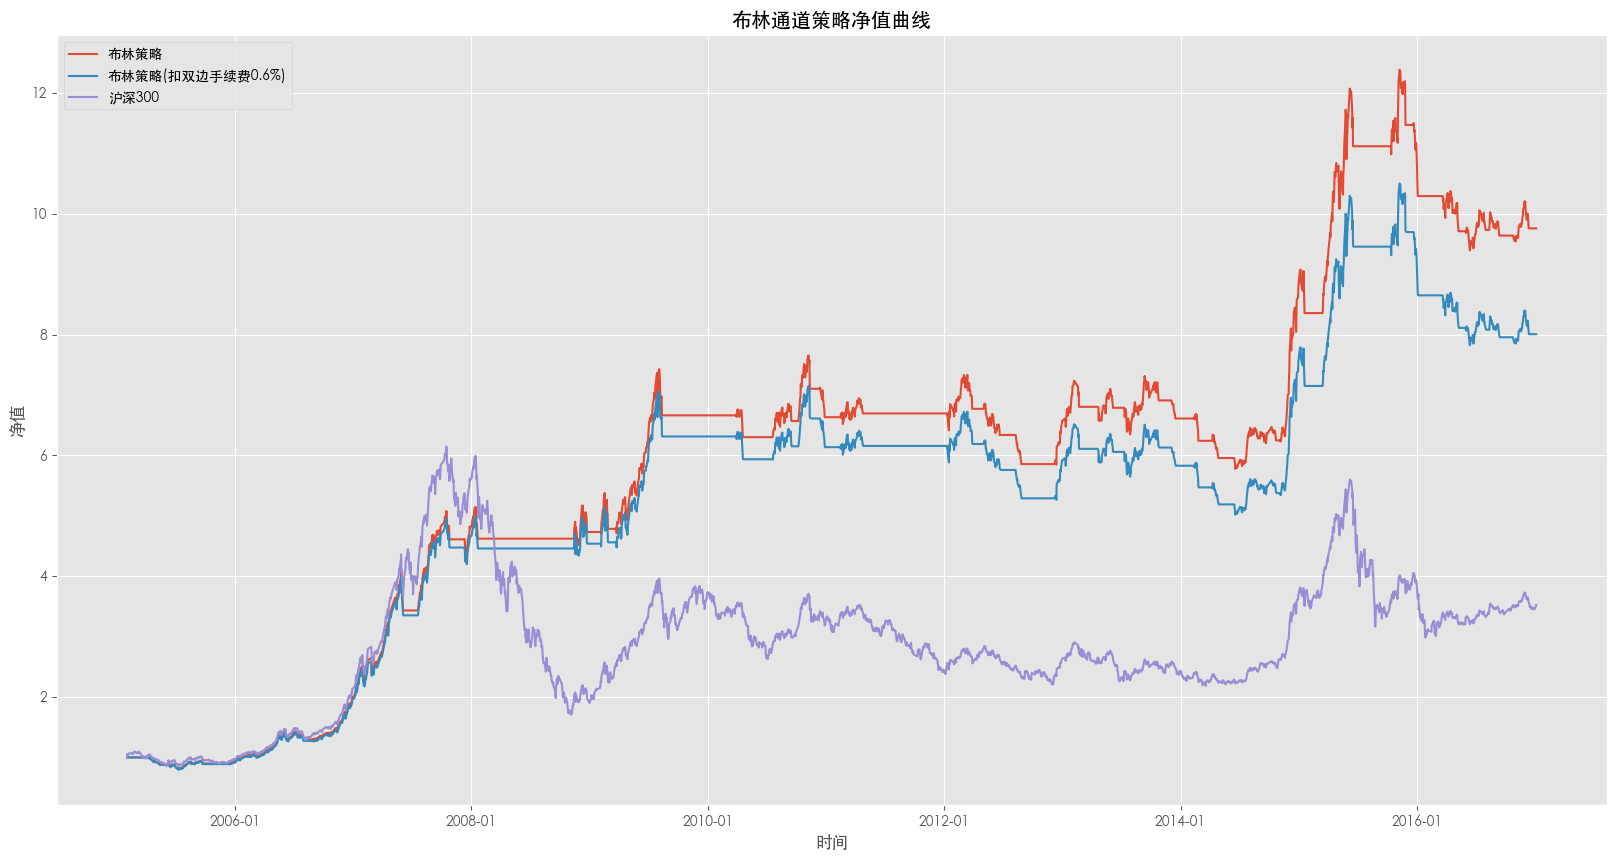

,年华收益率,累计收益,最大回撤,夏普
策略,21.92%,876.13%,-24.52%,117.37%
策略扣双向费率,19.84%,700.86%,-29.78%,107.96%


In [7]:
BBANDS_Strategy(df1)

## 阻力位与支撑位的定值使用方式的确有效，尤其是在大趋势中能获得巨额收益；但同时它的缺点也十分明显，即在等待突破时产生的滞后性，这使得它们在震荡行情中不断亏损。布林带突破策略在震荡期间出现了持续亏损，均线策略在无交易成本中表现虽不错，但交易成本对其冲击巨大，考虑交易成本之后，均线策略在震荡期间的回撤以及净值都不甚理想。

# RSRS指标择时策略构建：
## 不再把阻力位和支撑位看成定值，而是看成相对值。1.阻力位与支撑位实质上反应了交易者对目前市场状态顶底的一种预期判断。如果这种判断容易改变，就表明阻力位与支撑位的强度是弱的。2.如果支撑位的强度小，作用弱于阻力位，则表明市场参与者对于支撑位的分歧大于对于阻力位的分歧，市场接下来更倾向于向熊市转变。而如果支撑位的强度大，作用强于阻力位，则表示市场参与者对于支撑位的认可度更高于对于阻力位的认可度，市场更倾向于在牛市转变。
## 为什么选择最高价和最低价作为支撑位和阻力位的代表？
## 从最高价与最低价的形成机制出发，每日的最高价与最低价就是一种阻力位与支撑位，它是当日全体市场参与者的交易行为所认可的阻力与支撑。由于我们并非用支撑位与阻力位作突破或反转交易的阈值，而是更关注市场参与者们对于阻力位与支撑位的定位一致性。当日最高价与最低价能迅速反应近期市场对于阻力位与支撑位态度的性质，是我们使用最高价与最低价的最重要原因。
## 建立如下般最高价与最低价之间的线性模型：
## high = alpha + beta*low + epsilon， epsilon ~ N(0,sigma)
## 当斜率值很大时，支撑强度强于阻力强度。从最高价最低价序列来看，最高价变动比最低价迅速。当斜率值很小时，阻力强度强于支撑强度。从最高价最低价序列来看，最高价变动比最低价缓慢。这就是模型指标的理论依据。


In [8]:
# 计算RSRS指标
import statsmodels.api as sm

def Cal_RSRS(data,N):
    df = data.copy()
    beta_list = [np.nan] * (N-1)
    r2_list = [np.nan] * (N-1)
    for i in range(len(df)-N+1):
        y = df['high'].iloc[i:i+N].values
        x = df['low'].iloc[i:i+N].values
        if np.isnan(y).any() or np.isnan(x).any():
            beta_list.append(np.nan)
            r2_list.append(np.nan)
            continue
        X = sm.add_constant(x)
        model = sm.OLS(y,X).fit()
        beta_list.append(model.params[1])        
        r2_list.append(model.rsquared)
    df['RSRS'] = beta_list
    df['r2'] = r2_list
    return df

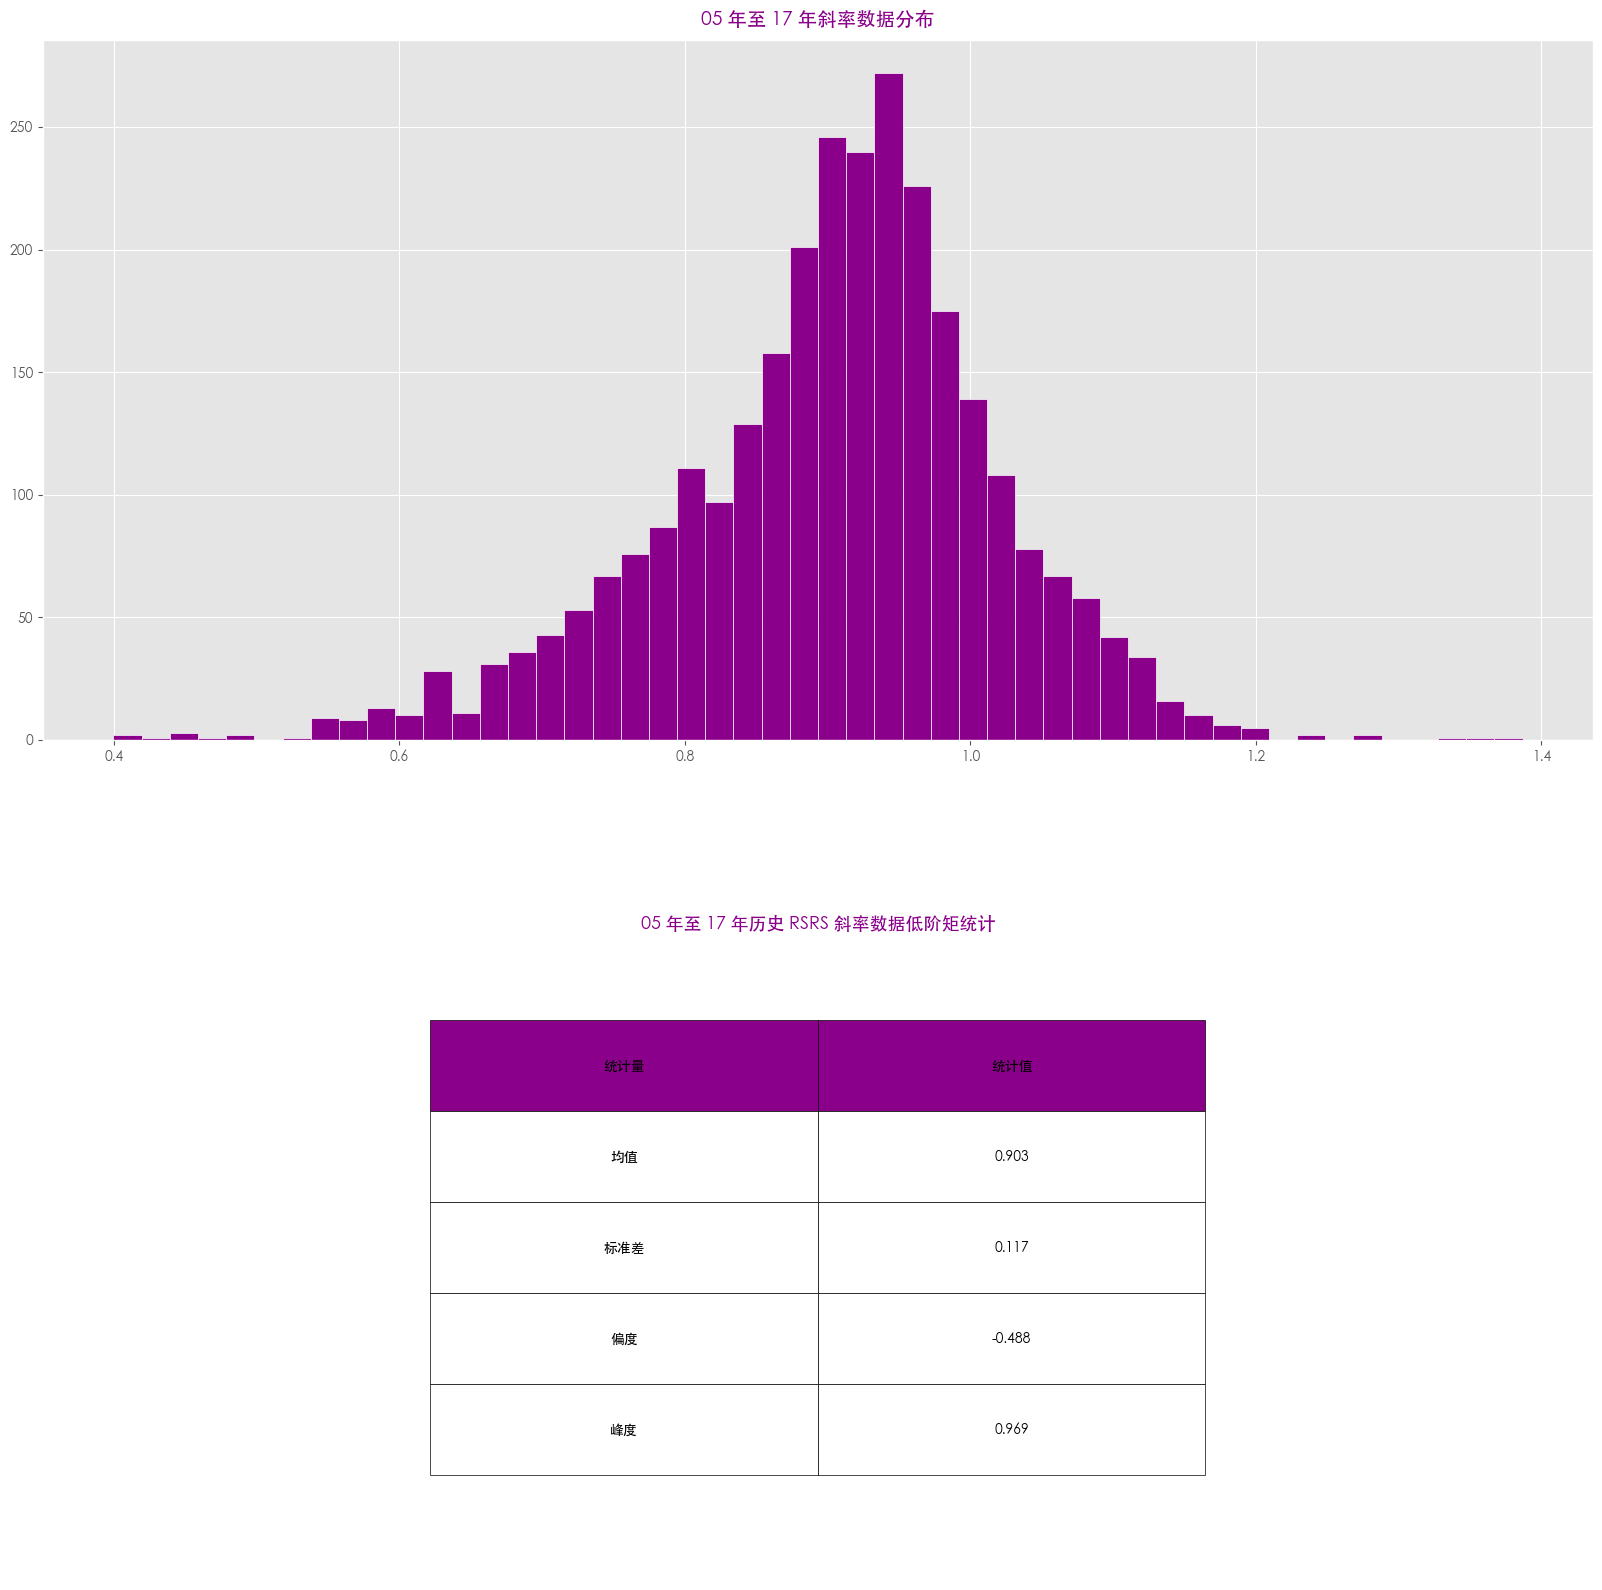

In [9]:
RSRS_df = Cal_RSRS(df,18)
beta = RSRS_df['RSRS'].dropna().values
stats_dict={
    '均值' : np.mean(beta),
    '标准差' : np.std(beta),
    '偏度' : pd.Series(beta).skew(),
    '峰度' : pd.Series(beta).kurtosis()
}

fig = plt.figure(figsize = (20,20))
ax1 = fig.add_subplot(211)
ax1.hist(beta, bins=50, color='#8B008B',edgecolor = 'white')
ax1.set_title('05 年至 17 年斜率数据分布', fontsize=14, color='#8B008B', pad=10)

ax2 = fig.add_subplot(212)
ax2.axis('off') 
ax2.text(0.5, 0.95, '05 年至 17 年历史 RSRS 斜率数据低阶矩统计',
         fontsize=13, color='#8B008B', ha='center', va='top', fontweight='bold')
table_data = [
    ['均值', f'{stats_dict["均值"]:.3f}'],
    ['标准差', f'{stats_dict["标准差"]:.3f}'],
    ['偏度', f'{stats_dict["偏度"]:.3f}'],
    ['峰度', f'{stats_dict["峰度"]:.3f}']
]
ax2.table(
    cellText=table_data,
    colLabels=['统计量', '统计值'],
    loc='center',
    cellLoc='center',
    colColours=['#8B008B', '#8B008B'],
    colWidths=[0.25, 0.25],
    bbox=[0.25, 0.15, 0.5, 0.65]
)


## 按照研报中描述，RSRS 斜率指标交易策略为：
1. 计算 RSRS 斜率。
2. 如果斜率大于1，则买入持有。
3. 如果斜率小于0.8，则卖出手中持股平仓。

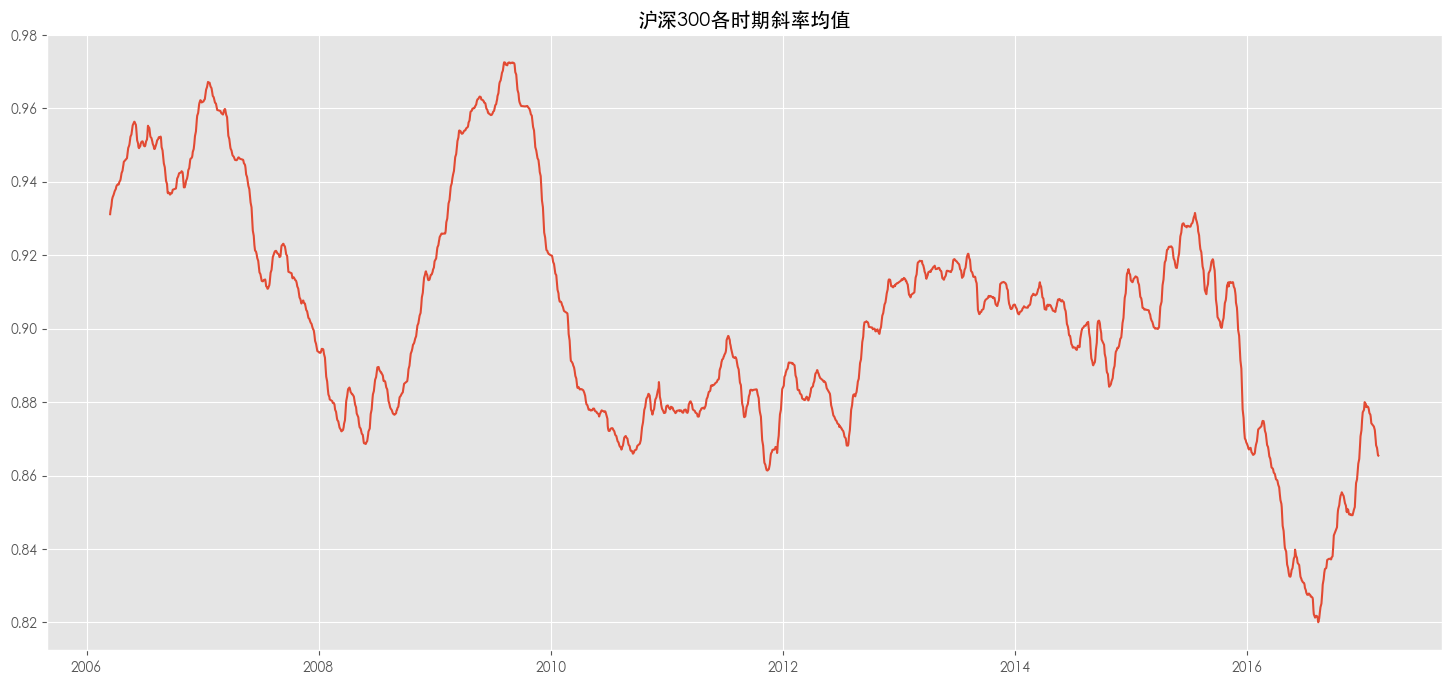

In [10]:
# 各期斜率情况
plt.figure(figsize=(18,8))
plt.title('沪深300各时期斜率均值')
plt.plot(RSRS_df['RSRS'].rolling(250).mean())

In [11]:
# 构造标准分RSRS
def Cal_RSRS_Zscore(data,N,M):
    df = Cal_RSRS(data,N)

    df = df.iloc[N-1:].copy()

    # 用拓展窗口处理前600天的z——score
    df['RSRS_Z'] = (df['RSRS'] - df['RSRS'].expanding().mean()) / df['RSRS'].expanding().std()
    
    # 用干净的 RSRS 计算标准分
    df.loc[df.index[M-1]:,'RSRS_Z'] = (df['RSRS'] - df['RSRS'].rolling(M).mean()) / df['RSRS'].rolling(M).std()
    
    # df['RSRS_Z'] = (df['RSRS'] - df['RSRS'].rolling(M).mean()) / df['RSRS'].rolling(M).std()
    
    return df


In [12]:
def RSRS_Strategy(data,N,M):
    df = data.copy()
    df = Cal_RSRS_Zscore(df,N,M)
    df = df.dropna(subset=['RSRS_Z'])  # 自动去掉前M-1天
    # df = df.iloc[N-1:].copy()
    # df = df.iloc[max(N,M)-1:].copy()

    print(f'回测起始日：{min(df.index)}')
    basic_signal = [0]*len(df)
    for i in range(len(df)):
        if df['RSRS'].iloc[i] > 1:
            basic_signal[i] = 1
        elif df['RSRS'].iloc[i] < 0.8:
            basic_signal[i] = 0
        else:
            basic_signal[i] = basic_signal[i-1]
    df['basic_signal'] = basic_signal
    df['basic_signal'] = df['basic_signal'].shift(1).fillna(0)

    z_signal = [0]*len(df)
    for i in range(len(df)):
        if df['RSRS_Z'].iloc[i] > 0.7:
            z_signal[i] = 1
        elif df['RSRS_Z'].iloc[i] < -0.7:
            z_signal[i] = 0
        else:
            z_signal[i] = z_signal[i-1]
    df['z_signal'] = z_signal
    df['z_signal'] = df['z_signal'].shift(1).fillna(0)

    df['ret'] = df['close'].pct_change().fillna(0)
    
    df['BASIC_CUM'] = (df['ret']*df['basic_signal']+1).cumprod()
    df['Z_CUM'] = (1+df['ret']*df['z_signal']).cumprod()
    benchmark = (df['ret']+1).cumprod()

    fig = plt.figure(figsize = (20,10))
    ax = fig.add_subplot(111)
    ax.plot(df['BASIC_CUM'],label='斜率指标策略')
    ax.plot(df['Z_CUM'],label='标准分指标策略')
    ax.plot(benchmark,label='沪深300')

    ax.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))
    ax.legend(loc = 'best')
    ax.set_xlabel('时间')
    ax.set_ylabel('收益净值')
    ax.set_title('RSRS指标策略净值曲线')
    plt.show()
    
    display(HTML(summary(df).to_html()))

def summary(data,signal_list=['basic_signal','z_signal']):
    df = data.copy()
    summary_dic = {}
    index_name = ('年化收益率,累计收益率,夏普比率,最大回撤,持仓总天数,交易次数,平均持仓天数,获利天数,'
    '亏损天数,胜率(按天),平均盈利率(按天),平均亏损率(按天),平均盈亏比(按天),盈利次数,亏损次数,'
    '单次最大盈利,单次最大亏损,胜率(按次),平均盈利率(按次),平均亏损率(按次),平均盈亏比(按次)').split(',')

    col_name = '斜率指标策略,标准分指标策略'.split(',')

    def format_x(x):
        return '{:.2%}'.format(x)

    for signal in signal_list:
        RET = df['ret']*df[signal]
        CUM_RET = (RET+1).cumprod()

        #年化利率
        annual_ret = CUM_RET[-1]**(250/len(CUM_RET)) - 1

        #累计收益率
        cum_rate = CUM_RET[-1] - 1

        #最大回撤
        cum_max = CUM_RET.cummax()
        mdd = np.min(CUM_RET/cum_max - 1)

        #夏普
        sharpe_ratio = RET.mean()/RET.std() * np.sqrt(250)

        #标记卖出时点
        tomorrow_signal = df[signal].shift(-1).fillna(0)
        mark = (df[signal] == 1) & (df[signal]!= tomorrow_signal)

        #交易次数
        trade_count = np.sum(mark)

        #持仓总天数
        total = np.sum(df[signal])

        #平均持仓天数
        mean_hold = total/trade_count

        #盈利天数
        win = np.sum(np.where(RET>0,1,0))

        #亏损天数
        lose = np.sum(np.where(RET<0,1,0))

        #胜率
        win_ratio = win/total

        #平均盈利率（天数）
        mean_win_ratio = np.sum(np.where(RET>0,RET,0)) / win

        #平均亏损率(天数)
        mean_lose_ratio = np.sum(np.where(RET<0,RET,0))/lose

        #盈亏比
        win_lose = win/lose

        #找出各个持仓期间的收益情况
        #1.先找出交易的节点（买和卖）
        temp_df = df.copy()
        yesterday_signal = temp_df[signal].shift(1).fillna(0)
        temp_df['fee'] = temp_df[signal] != yesterday_signal
        #2.累加找出各个持仓空仓时间段
        temp_df['mark'] = temp_df['fee'].cumsum()
        #3.分组聚合找到各持仓时间短的收益
        temp_df = temp_df[temp_df[signal] == 1].groupby('mark')['ret'].apply(
            lambda x: (1 + x).prod() - 1
        )

        #盈利次数
        win_count = np.sum(np.where(temp_df>0,1,0))

        #亏损次数
        lose_count = np.sum(np.where(temp_df<0,1,0))

        #单次最大盈利
        max_win = np.max(temp_df)

        #单词最大亏损
        max_lose = np.min(temp_df)

        # 胜率
        win_rat = win_count/len(temp_df)
        # 平均盈利率（次）
        mean_win = np.sum(np.where(temp_df > 0, temp_df, 0))/win_count
        # 平均亏损率（次）
        mean_lose = np.sum(np.where(temp_df<0, temp_df, 0))/lose_count
        # 盈亏比(次)
        mean_win_lose = np.abs(mean_win/mean_lose)

        summary_dic[signal] = [format_x(annual_ret), format_x(cum_rate),sharpe_ratio,format_x(
        mdd), total, trade_count, mean_hold, win, lose, format_x(win_ratio), format_x(mean_win_ratio),
        format_x(mean_lose_ratio), win_lose, win_count, lose_count, format_x(
            max_win), format_x(max_lose),
        format_x(win_rat), format_x(mean_win), format_x(mean_lose), mean_win_lose]

    summary_df=pd.DataFrame(summary_dic,index=index_name)
    summary_df.columns=col_name
    return summary_df
        
        

回测起始日：2005-03-08 00:00:00


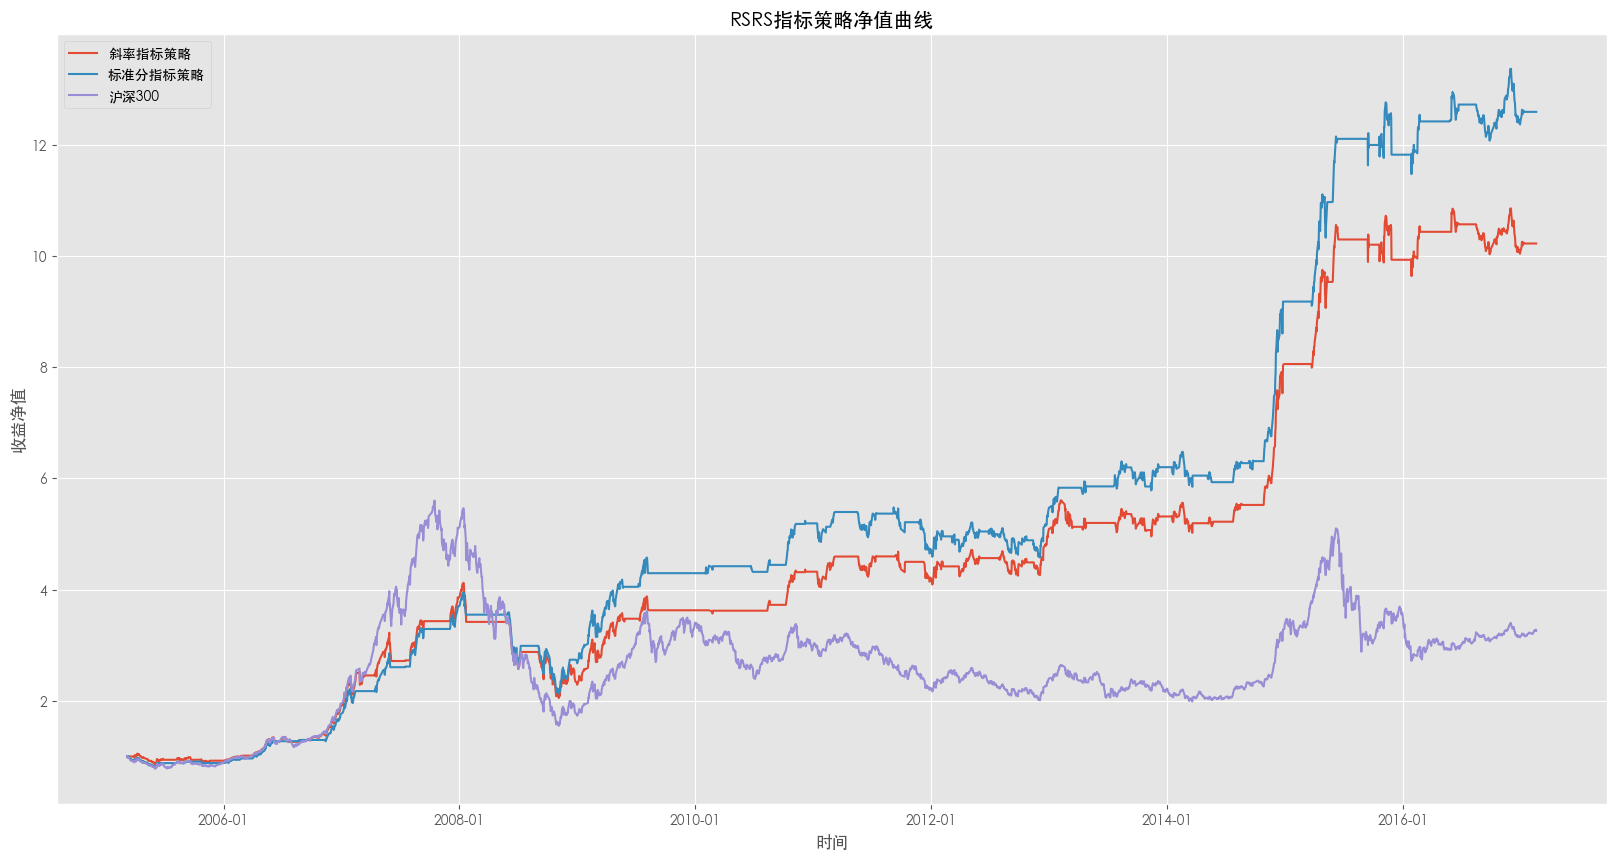

,斜率指标策略,标准分指标策略
年化收益率,22.14%,24.35%
累计收益率,922.62%,1159.34%
夏普比率,1.101801,1.247947
最大回撤,-50.26%,-46.16%
持仓总天数,1392.0,1317.0
交易次数,44,47
平均持仓天数,31.636364,28.021277
获利天数,778,732
亏损天数,614,585
胜率(按天),55.89%,55.58%


In [13]:
RSRS_Strategy(df,18,600)

#  标准分策略的弊端：08年熊市中期标准分策略误抄底，在半山腰买入，后续平仓已经产生较大回撤。因此使用解释系数修正标准分指标，可以削弱拟合效果对决策的影响，比如标准分很大但是拟合效果差，在修正之后就变得温和很多。简单来说，使用解释系数进行修正，可以使强烈看好变成--谨慎看好。使强烈看空变成---谨慎看空，从而达到削弱拟合和效果不好的影响。

In [14]:
# 构造修正标准分
def Cal_RSRS_Revise(data,N,M):
    df = Cal_RSRS_Zscore(data,N,M)
    # 使用r2对标准分进行修正
    df['RSRS_R'] = df['RSRS_Z']*df['r2']
    return df

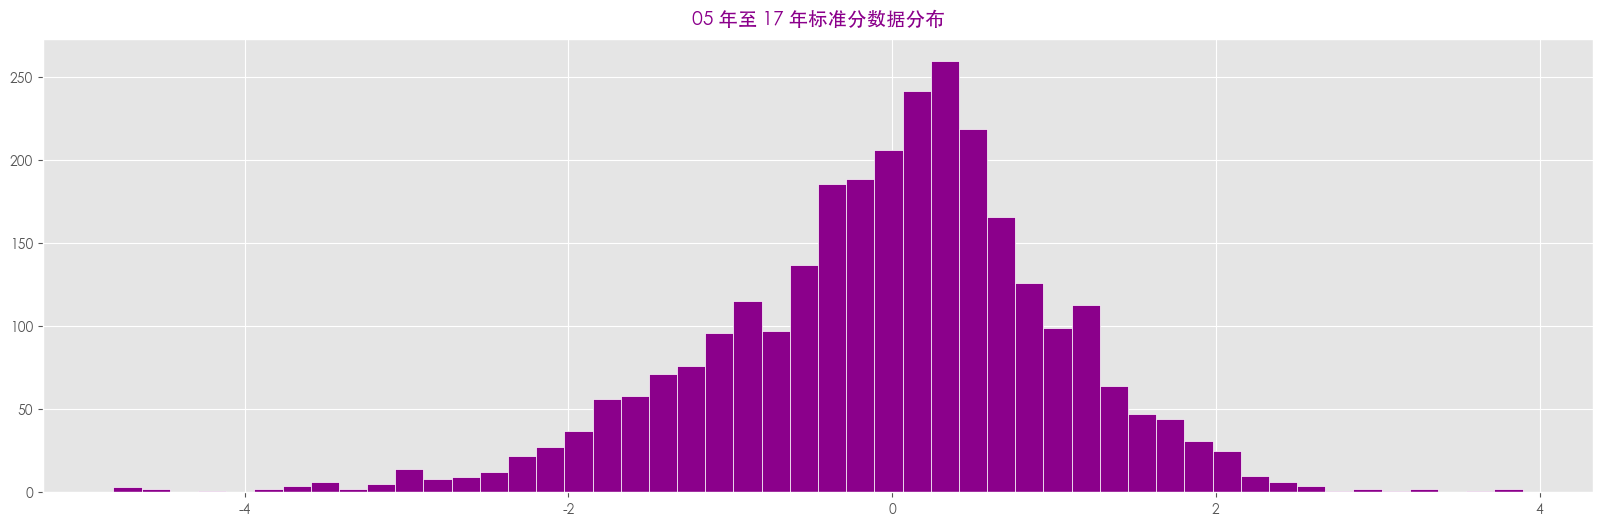

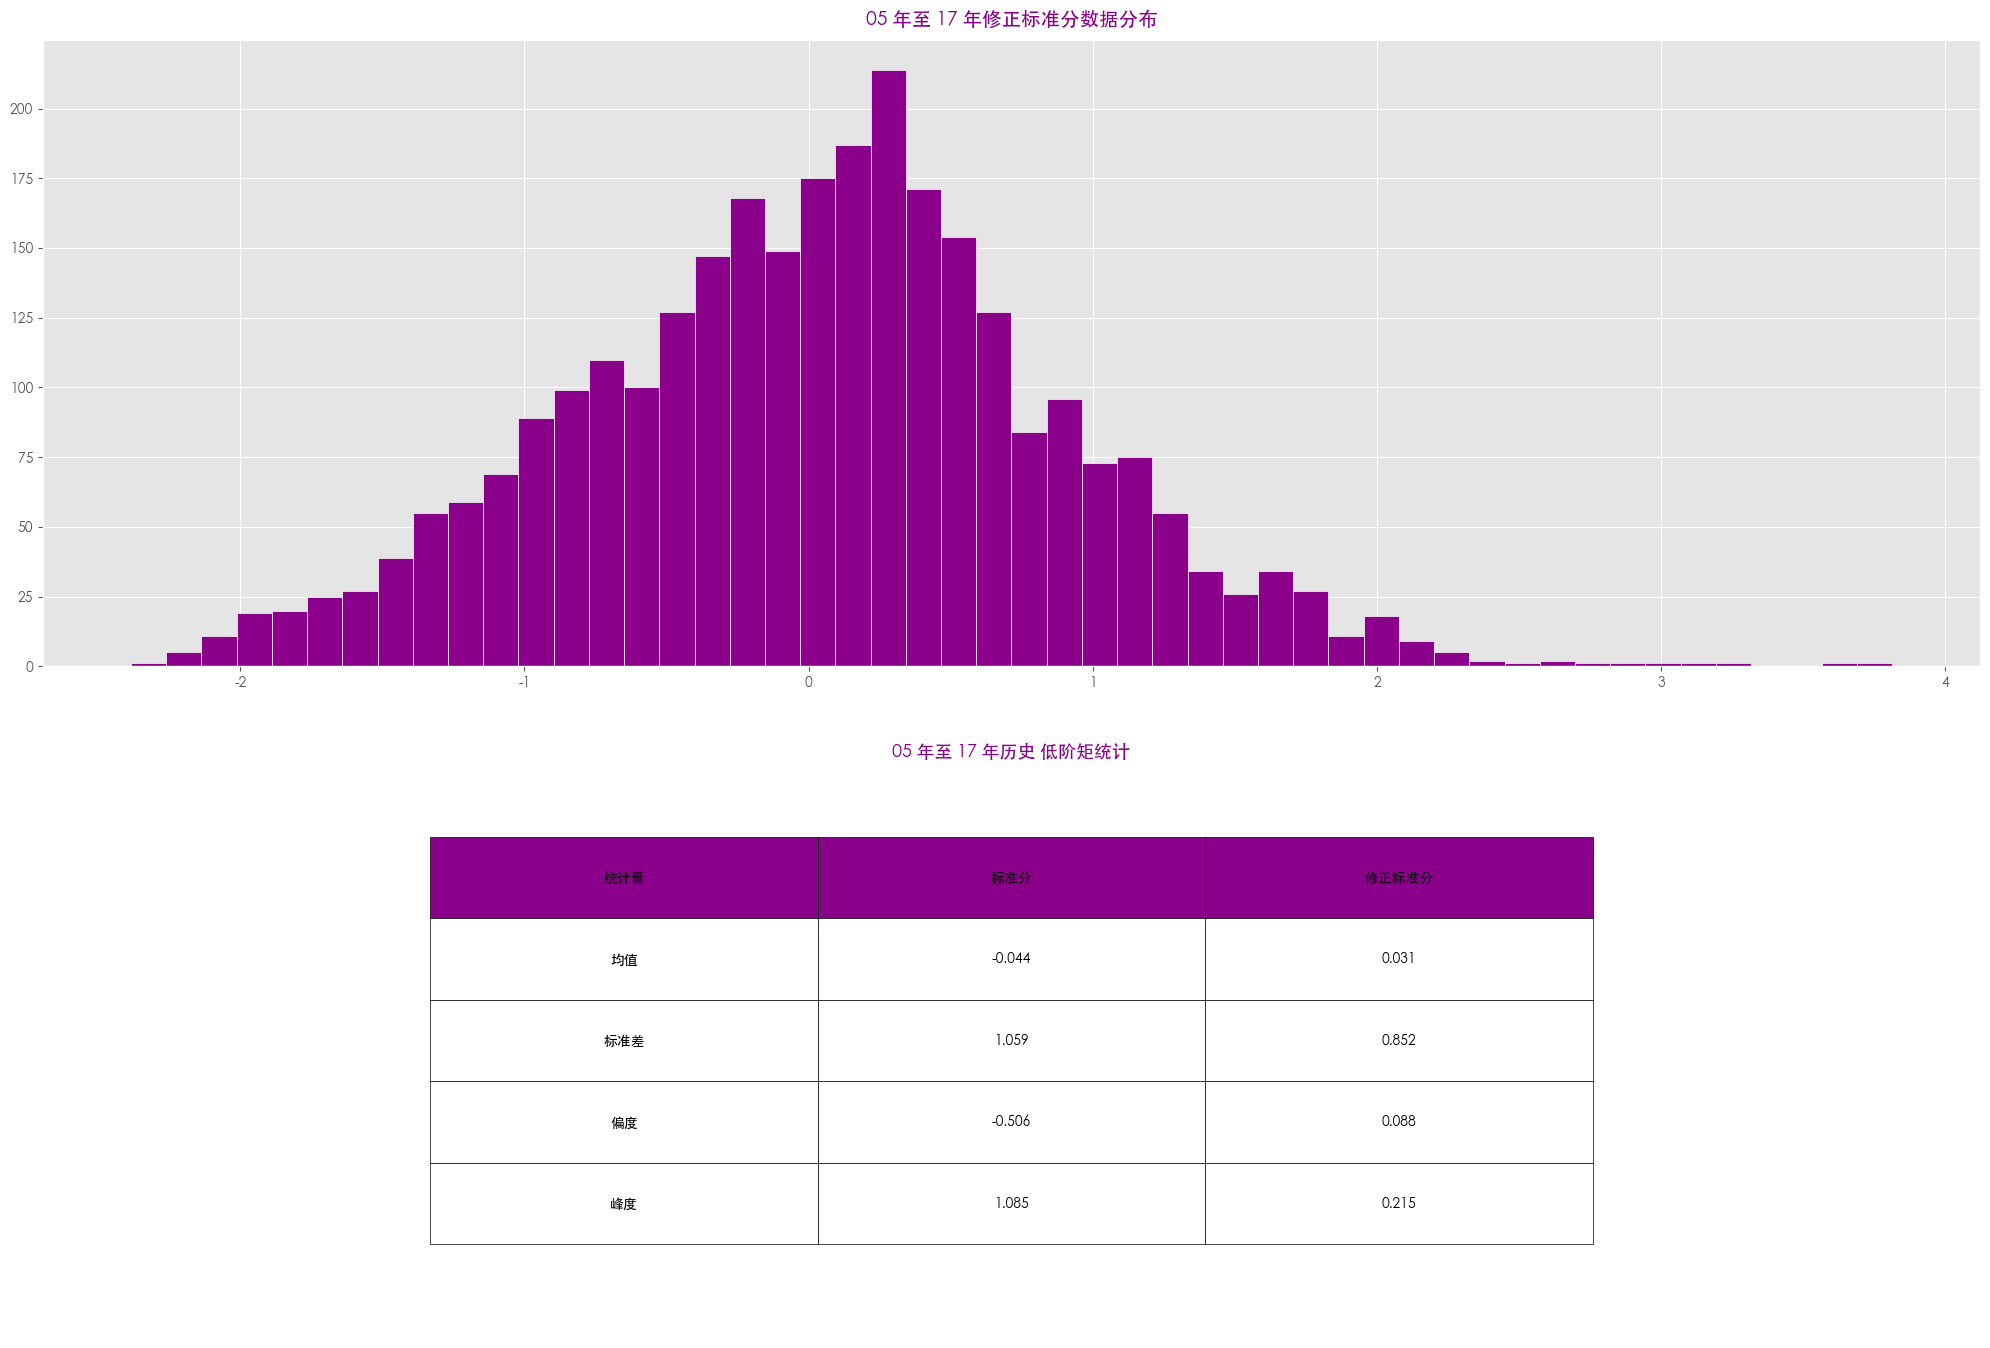

In [15]:
RSRS_Z = Cal_RSRS_Zscore(df,18,600)
RSRS_Z = RSRS_Z['RSRS_Z'].dropna().values
stats_dict1={
    '均值' : np.mean(RSRS_Z),
    '标准差' : np.std(RSRS_Z),
    '偏度' : pd.Series(RSRS_Z).skew(),
    '峰度' : pd.Series(RSRS_Z).kurtosis()
}

fig = plt.figure(figsize = (20,20))
ax1 = fig.add_subplot(311)
ax1.hist(RSRS_Z, bins=50, color='#8B008B',edgecolor = 'white')
ax1.set_title('05 年至 17 年标准分数据分布', fontsize=14, color='#8B008B', pad=10)


RSRS_R = Cal_RSRS_Revise(df,18,600)
RSRS_R = RSRS_R['RSRS_R'].dropna().values
stats_dict2={
    '均值' : np.mean(RSRS_R),
    '标准差' : np.std(RSRS_R),
    '偏度' : pd.Series(RSRS_R).skew(),
    '峰度' : pd.Series(RSRS_R).kurtosis()
}

fig = plt.figure(figsize = (20,20))
ax2 = fig.add_subplot(312)
ax2.hist(RSRS_R, bins=50, color='#8B008B',edgecolor = 'white')
ax2.set_title('05 年至 17 年修正标准分数据分布', fontsize=14, color='#8B008B', pad=10)



ax3 = fig.add_subplot(313)
ax3.axis('off') 
ax3.text(0.5, 0.95, '05 年至 17 年历史 低阶矩统计',
         fontsize=13, color='#8B008B', ha='center', va='top', fontweight='bold')
table_data = [
    ['均值', f'{stats_dict1["均值"]:.3f}', f'{stats_dict2["均值"]:.3f}'],
    ['标准差', f'{stats_dict1["标准差"]:.3f}', f'{stats_dict2["标准差"]:.3f}'],
    ['偏度', f'{stats_dict1["偏度"]:.3f}', f'{stats_dict2["偏度"]:.3f}'],
    ['峰度', f'{stats_dict1["峰度"]:.3f}', f'{stats_dict2["峰度"]:.3f}']
]

ax3.table(
    cellText=table_data,
    colLabels=['统计量', '标准分', '修正标准分'],
    loc='center',
    cellLoc='center',
    colColours=['#8B008B', '#8B008B', '#8B008B'],
    colWidths=[0.2, 0.2, 0.2],
    bbox=[0.2, 0.15, 0.6, 0.65]
)

plt.tight_layout()
plt.show()

In [16]:
def Pred_Plot(data,factor_name,after=10,title=None,probability=True,prt=True):
    df = data.copy()
    df['ret'] = df['close'].shift(-after)/df['close'] -1
    
    df['group'] = pd.cut(df[factor_name],50)
    if probability:
        pred = df.groupby('group')['ret'].apply(lambda x: (x.dropna() > 0).mean())
    else:
        pred = df.groupby('group')['ret'].apply(lambda x: x.dropna().mean())

    if prt:
        group = np.arange(len(pred))
        fig = plt.figure(figsize = (20,10))
        ax = fig.add_subplot(111)
        ax.bar(group,pred.values,width=0.8, edgecolor='white', linewidth=0.3,color='#8B008B')
        ax.set_title(title)
        x_labels = [f'{g:.1f}' for g in df.groupby('group')[factor_name].mean().values]
        ax.set_xticks(group[::2])
        ax.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), 2)], rotation=45, ha='right')
        plt.show()

    else:
        return pred

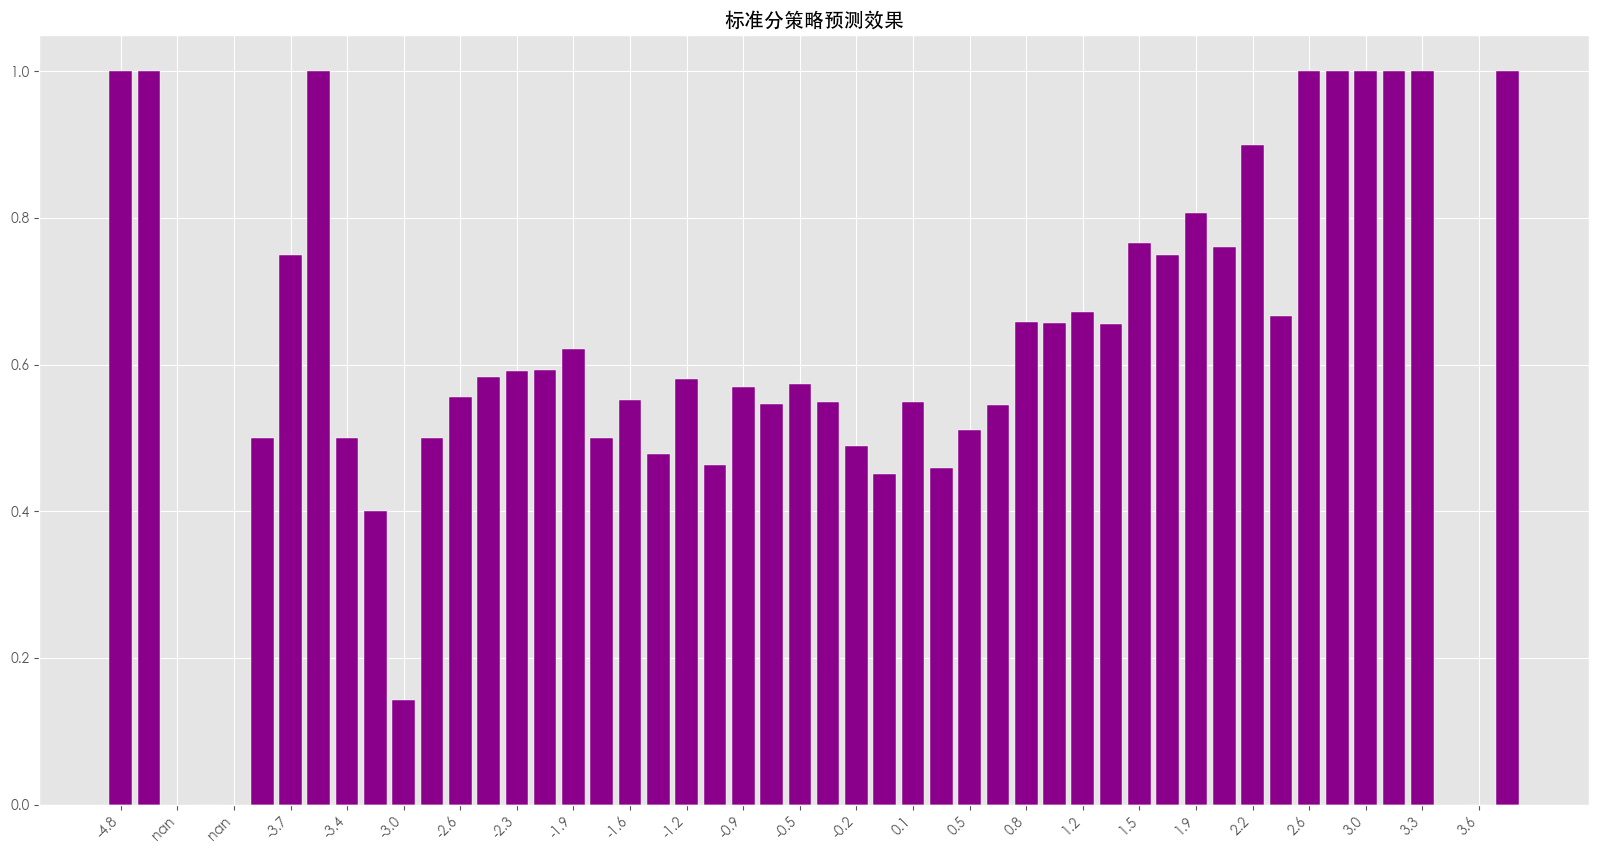

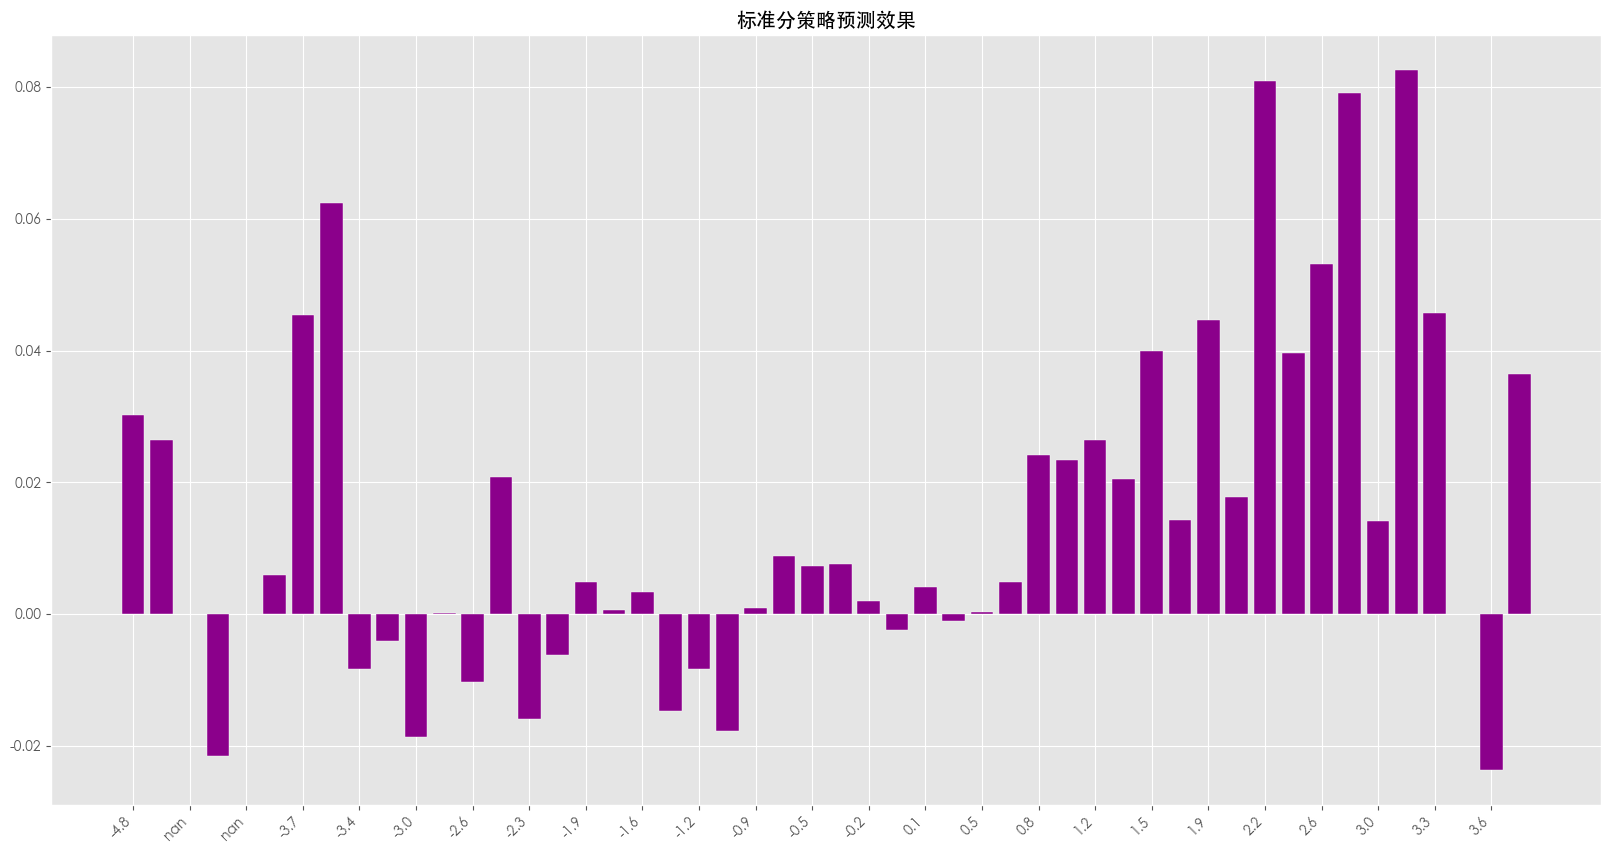

In [17]:
data_Z = Cal_RSRS_Zscore(df,18,600)
data_R = Cal_RSRS_Revise(df,18,600)
Pred_Plot(data_Z,'RSRS_Z',title ='标准分策略预测效果')
Pred_Plot(data_Z,'RSRS_Z',title ='标准分策略预测效果',probability=False)

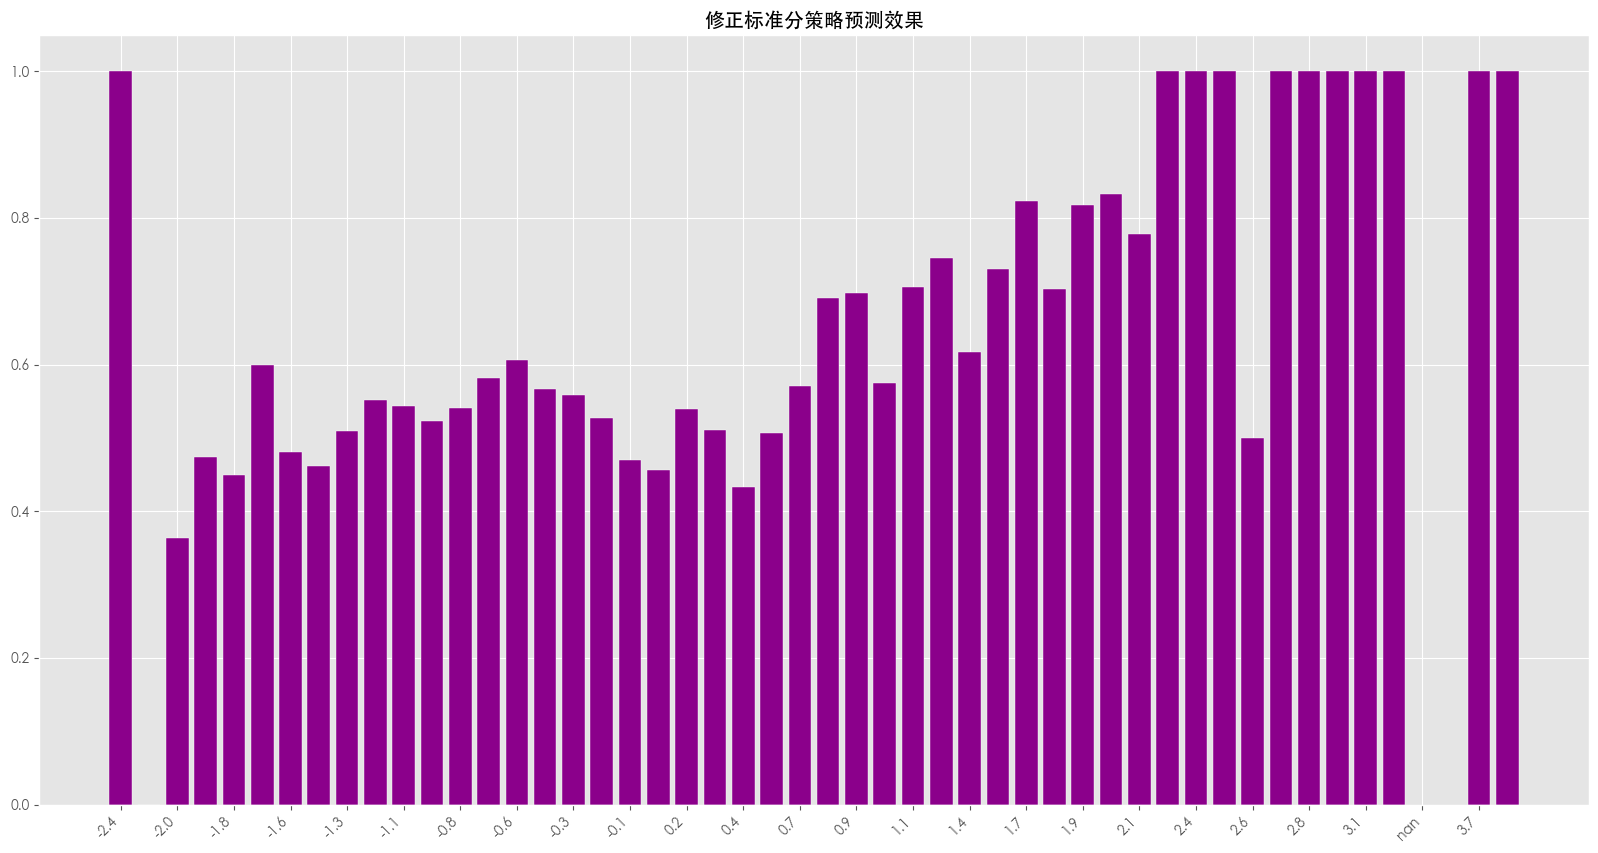

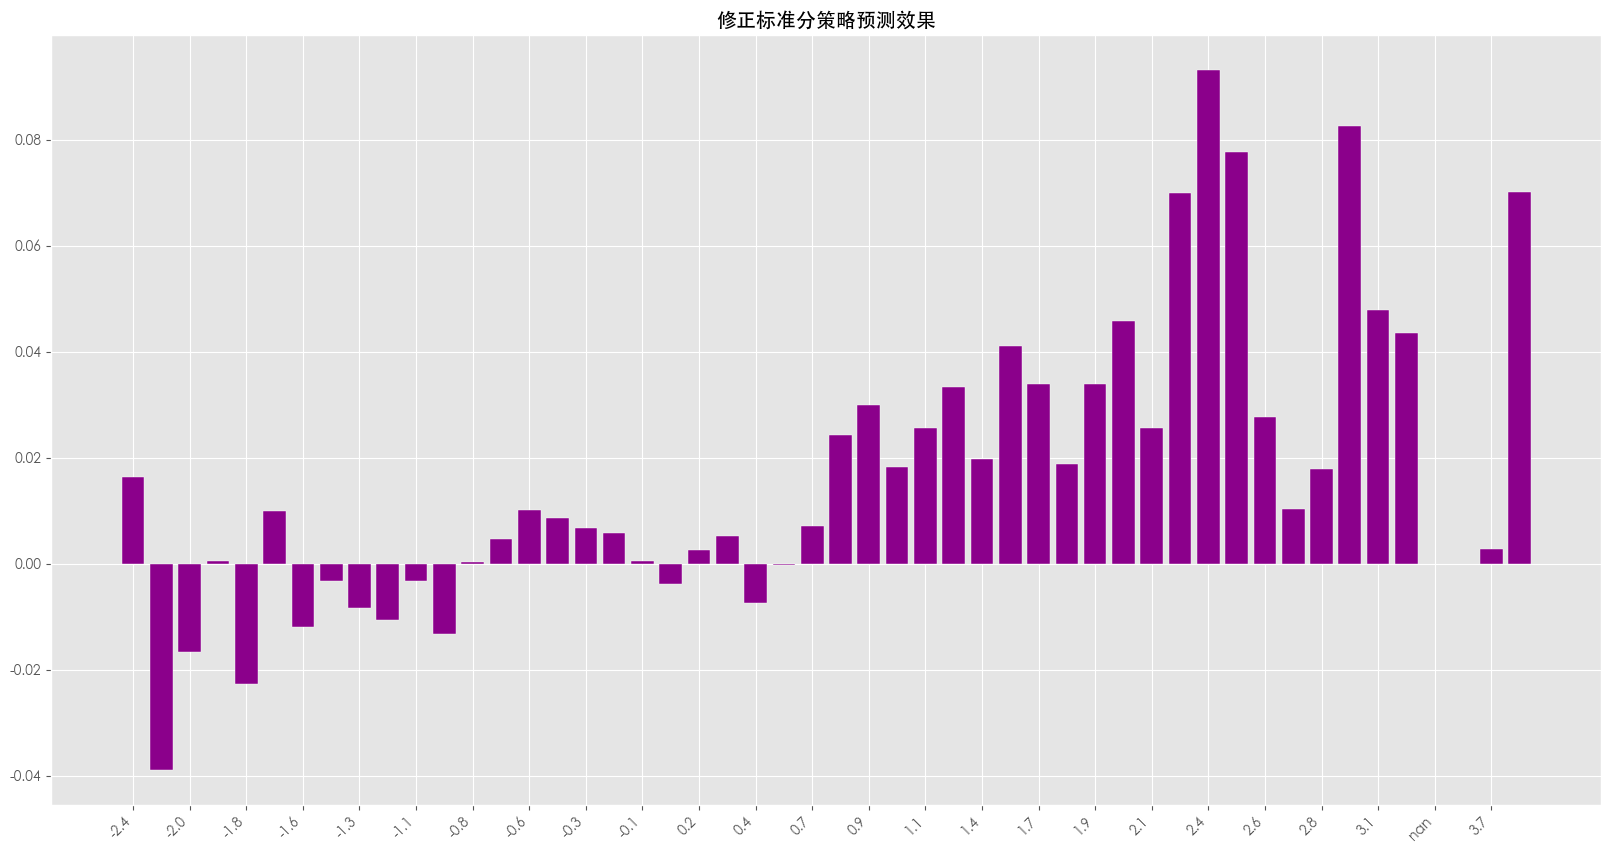

In [18]:
Pred_Plot(data_R,'RSRS_R',title ='修正标准分策略预测效果')
Pred_Plot(data_R,'RSRS_R',title ='修正标准分策略预测效果',probability=False)

In [19]:
def Factor_Corr(data, factor_name, after=10, title=None):
    # 1. 期望收益
    zr = Pred_Plot(data, factor_name, after=after, prt=False, probability=False)
    zr.index = zr.index.categories.right
    zr = zr.dropna().reset_index()
    zr.columns = ['factor', 'ret']
    rq = zr.query('factor>0')
    nrq = zr.query('factor<0')

    # 2. 上涨概率
    zp = Pred_Plot(data, factor_name, after=after, prt=False, probability=True)
    zp.index = zp.index.categories.right
    zp = zp.dropna().reset_index()
    zp.columns = ['factor', 'ret']
    pq = zp.query('factor>0')
    npq = zp.query('factor<0')

    # 3. 计算并输出
    print('-' * 30, '\n%s:\n' % (title or factor_name))
    print(f'{factor_name}右侧指标与期望收益相关系数:{np.corrcoef(rq["factor"], rq["ret"])[0][1]:.2f}')
    print(f'{factor_name}右侧指标与未来上涨概率相关系数:{np.corrcoef(pq["factor"], pq["ret"])[0][1]:.2f}')
    print(f"{'-' * 30}\n{title or factor_name}:\n")
    print(f'{factor_name}左侧指标与期望收益相关系数:{np.corrcoef(nrq["factor"], nrq["ret"])[0][1]:.2f}')
    print(f'{factor_name}左侧指标与未来上涨概率相关系数:{np.corrcoef(npq["factor"], npq["ret"])[0][1]:.2f}')
    print(f"{'-' * 30}\n{title or factor_name}:\n")
    print(f'{factor_name}整体指标与期望收益相关系数:{np.corrcoef(zr["factor"], zr["ret"])[0][1]:.2f}')
    print(f'{factor_name}整体指标与未来上涨概率相关系数:{np.corrcoef(zp["factor"], zp["ret"])[0][1]:.2f}')

# 使用示例（与你第二段代码完全等价）：
Factor_Corr(data_Z, 'RSRS_Z', after=10, title='标准分')
Factor_Corr(data_R, 'RSRS_R', after=10, title='修正标准分')

------------------------------ 
标准分:

RSRS_Z右侧指标与期望收益相关系数:0.45
RSRS_Z右侧指标与未来上涨概率相关系数:0.44
------------------------------
标准分:

RSRS_Z左侧指标与期望收益相关系数:-0.32
RSRS_Z左侧指标与未来上涨概率相关系数:-0.21
------------------------------
标准分:

RSRS_Z整体指标与期望收益相关系数:0.43
RSRS_Z整体指标与未来上涨概率相关系数:0.32
------------------------------ 
修正标准分:

RSRS_R右侧指标与期望收益相关系数:0.58
RSRS_R右侧指标与未来上涨概率相关系数:0.86
------------------------------
修正标准分:

RSRS_R左侧指标与期望收益相关系数:0.44
RSRS_R左侧指标与未来上涨概率相关系数:0.13
------------------------------
修正标准分:

RSRS_R整体指标与期望收益相关系数:0.75
RSRS_R整体指标与未来上涨概率相关系数:0.76


## 可见虽然和研报中的相关系数在大小上有出入，但是基本的结论一致：1.标准分策略的右侧指标对未来10天的上涨概率以及期望收益具有较好的预测效果。2.经过修正，对标准分进行拟合效果的修正使得指标与沪深300 未来10 日收益率的整体相关性得以改善。因此，有了进一步推论：，是否右侧数据值域越广，其对未来收益率的预测越好？是否左侧数据值域越窄越好？能否通过改变标准分的分布来达到改善整体指标预测性的目的？（使整体分布进一步的右偏，可以强化指标的预测效果）
#  由此引申出另一指标：右侧标准分---它由修正标准分与斜率相乘得出，可以使原有分布右偏。下面展示右侧标准分的预测效果

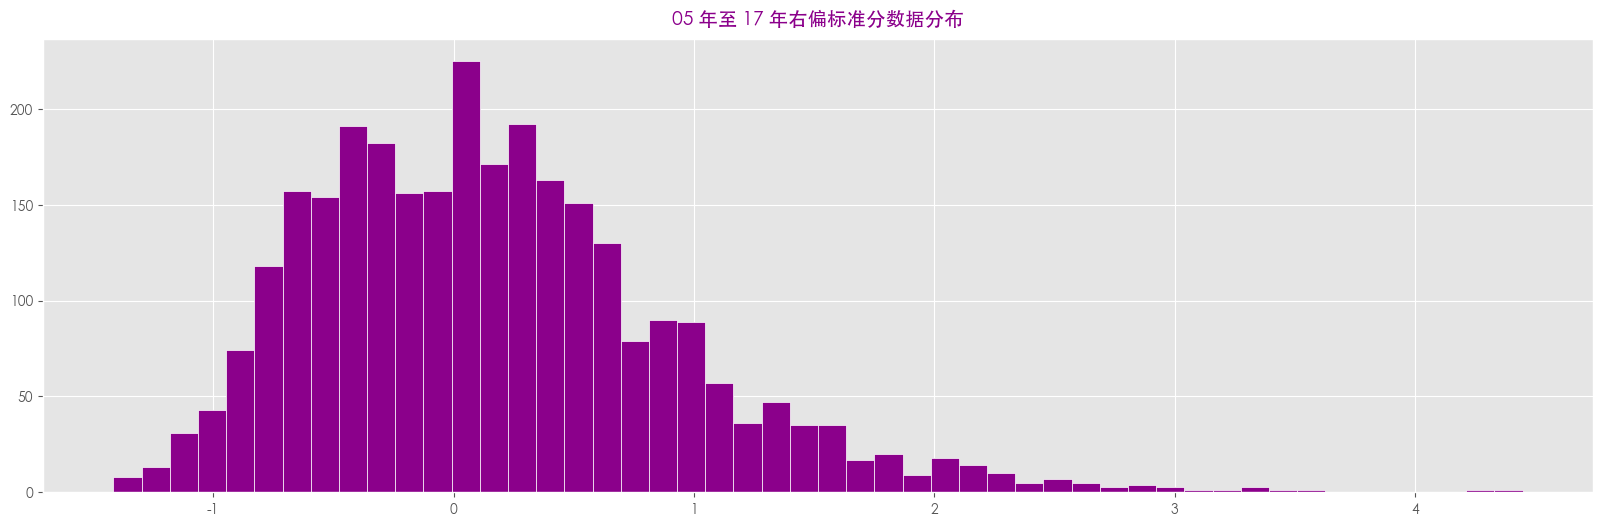

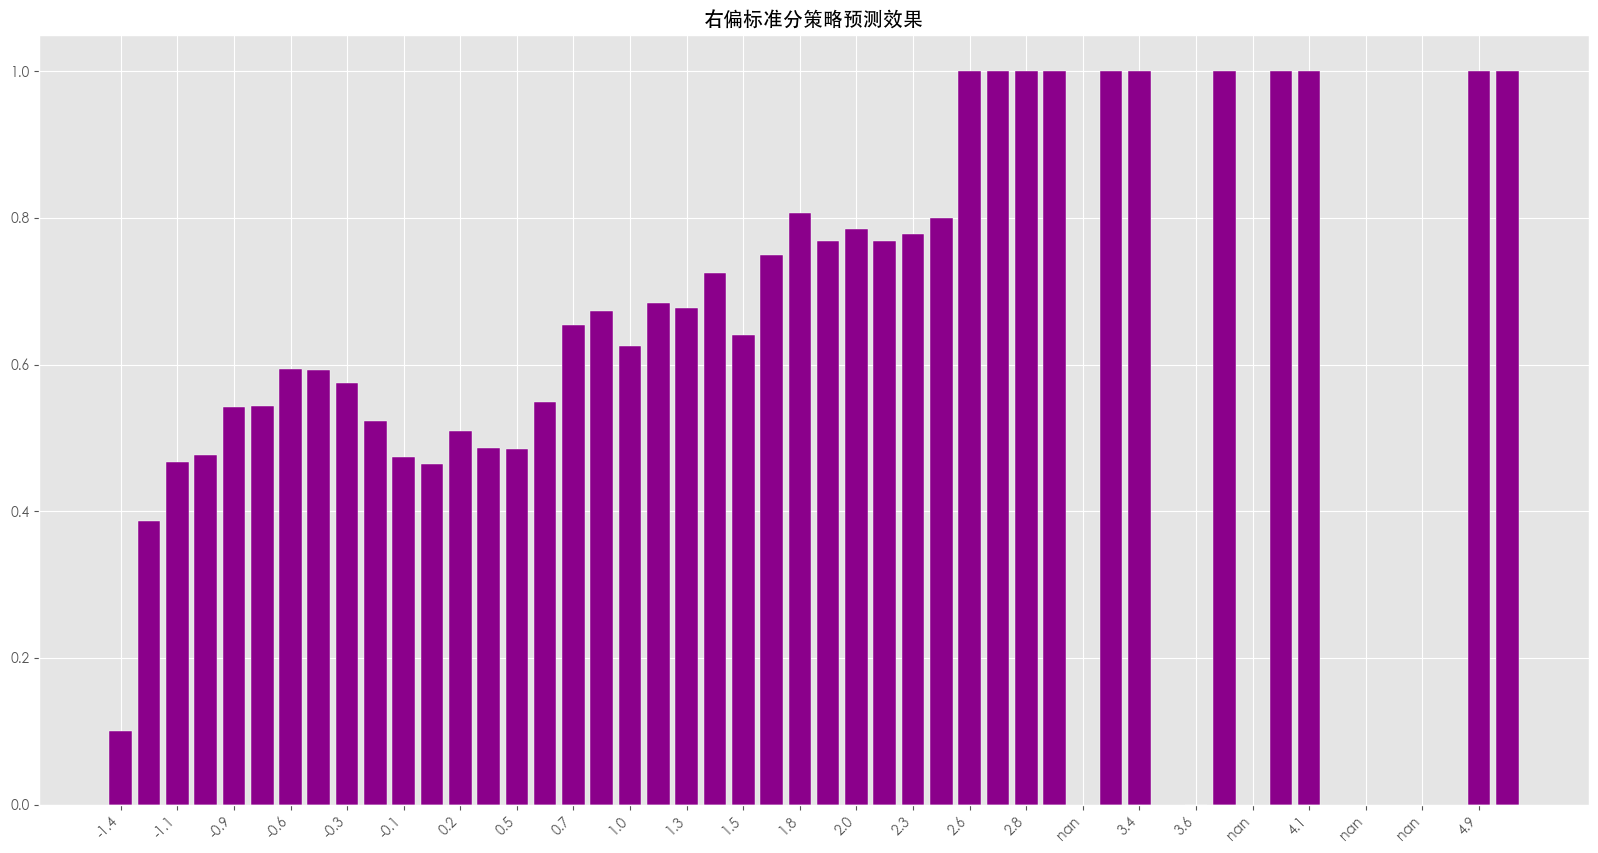

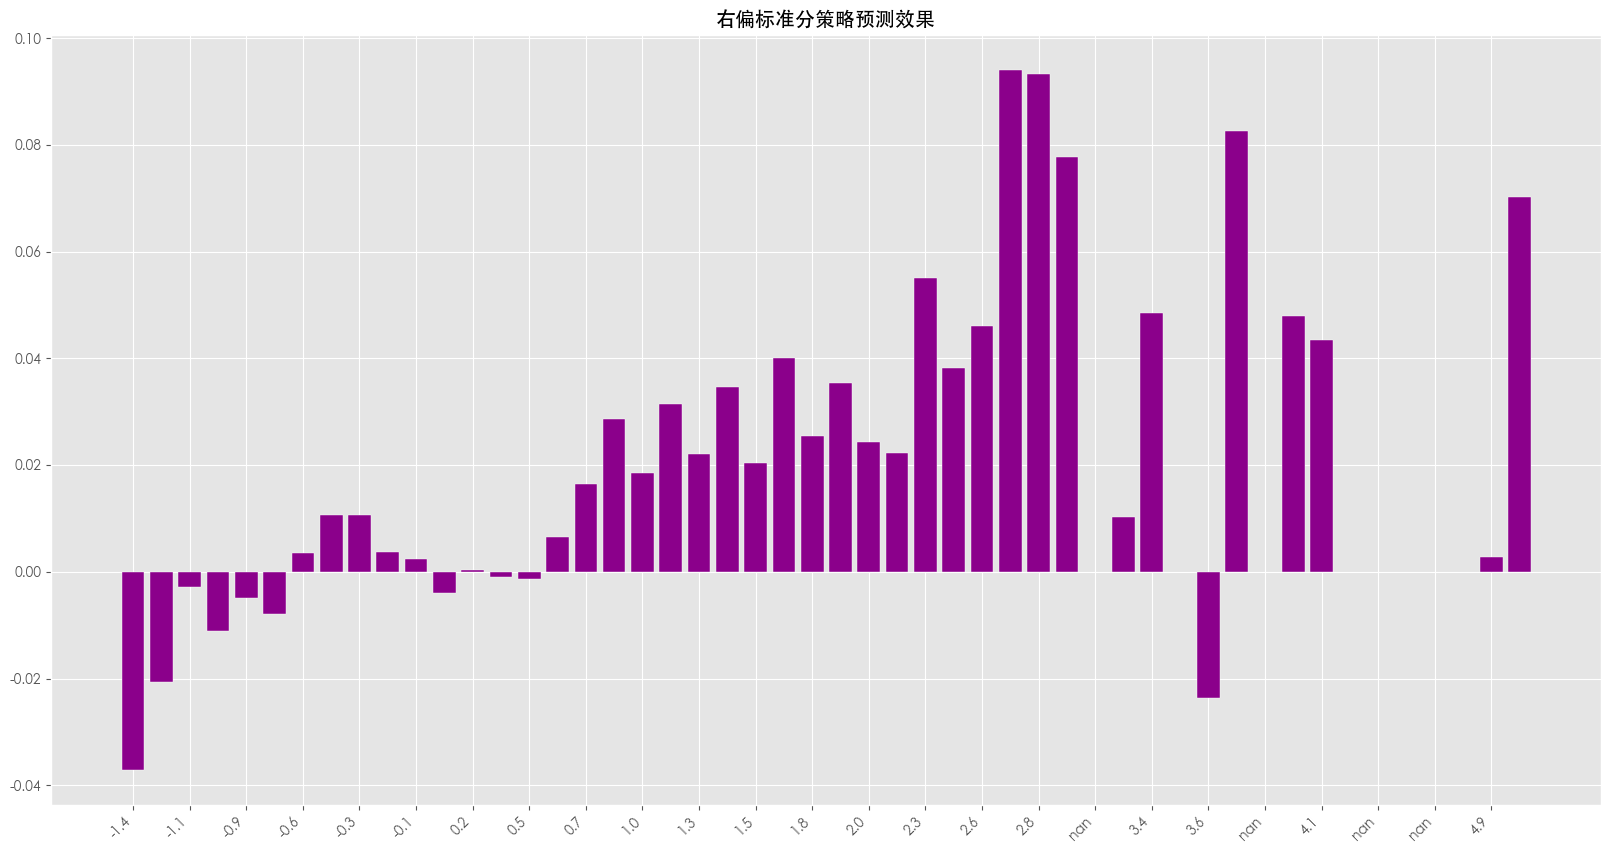

In [20]:
# 构造右偏标准分
def Cal_RSRS_Positive(data,N,M):
    df = Cal_RSRS_Revise(data,N,M)
    
    # 构造右偏标准分
    df['RSRS_P'] = df['RSRS_Z']*df['r2']*df['RSRS']
    return df

RSRS_P = Cal_RSRS_Positive(df,16,300)
RSRS_P = RSRS_P['RSRS_P'].dropna().values

fig = plt.figure(figsize = (20,20))
ax1 = fig.add_subplot(311)
ax1.hist(RSRS_P, bins=50, color='#8B008B',edgecolor = 'white')
ax1.set_title('05 年至 17 年右偏标准分数据分布', fontsize=14, color='#8B008B', pad=10)

data_P = Cal_RSRS_Positive(df,18,600)
Pred_Plot(data_P,'RSRS_P',title ='右偏标准分策略预测效果')
Pred_Plot(data_P,'RSRS_P',title ='右偏标准分策略预测效果',probability=False)

In [21]:
Factor_Corr(data_P, 'RSRS_P', after=10, title='右偏标准分')

------------------------------ 
右偏标准分:

RSRS_P右侧指标与期望收益相关系数:0.45
RSRS_P右侧指标与未来上涨概率相关系数:0.59
------------------------------
右偏标准分:

RSRS_P左侧指标与期望收益相关系数:0.82
RSRS_P左侧指标与未来上涨概率相关系数:0.65
------------------------------
右偏标准分:

RSRS_P整体指标与期望收益相关系数:0.66
RSRS_P整体指标与未来上涨概率相关系数:0.72


回测起始日：2005-03-08 00:00:00


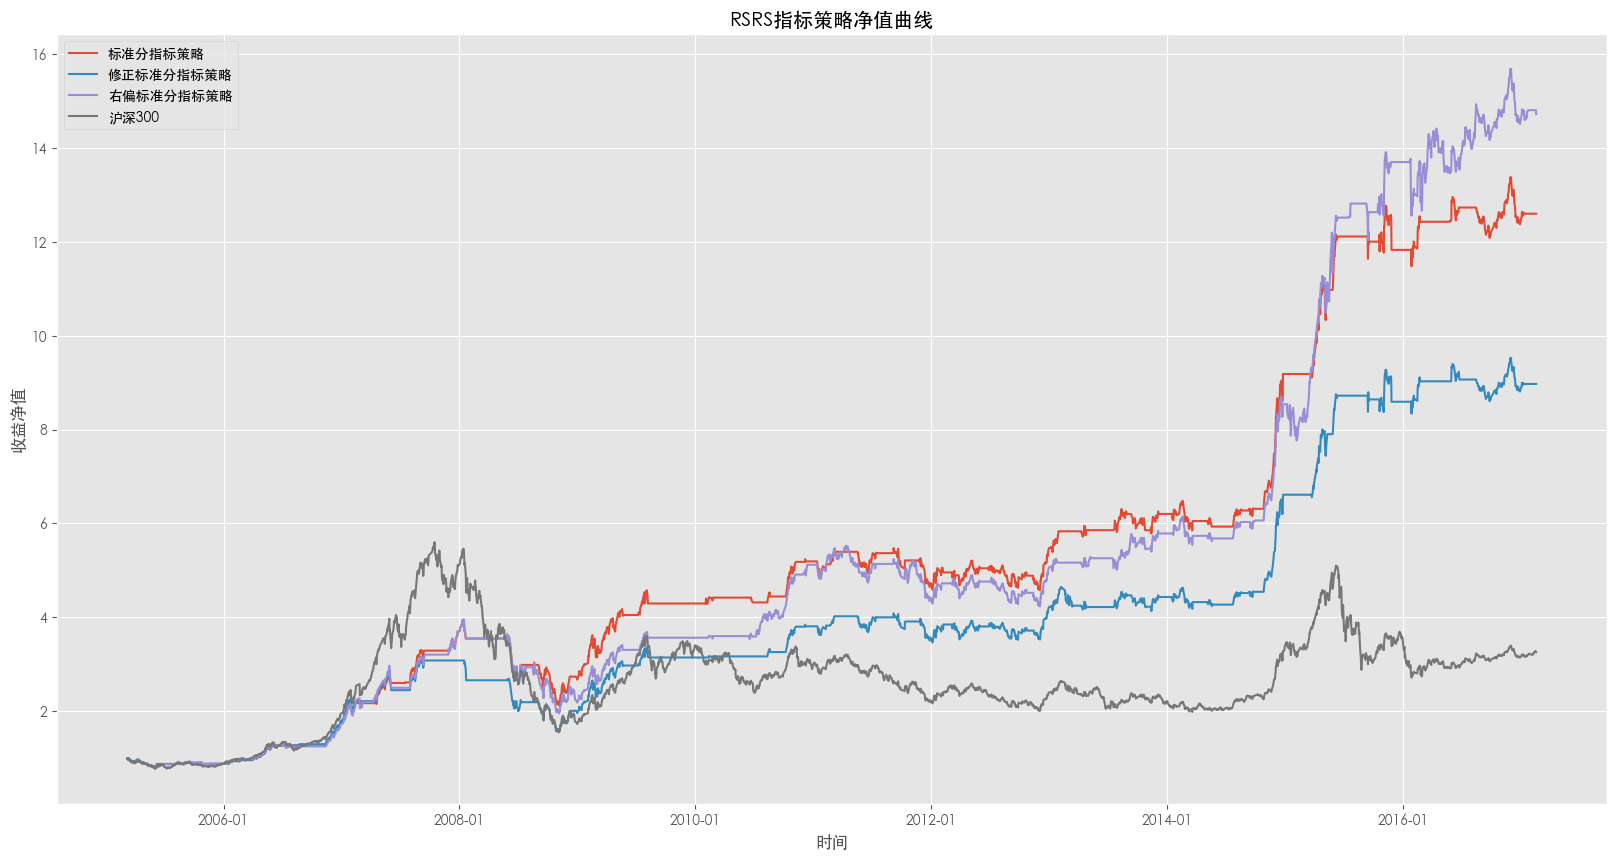

,标准分指标策略,修正标准分策略,右偏标准分策略
年化收益率,24.35%,20.77%,26.02%
累计收益率,1159.34%,797.01%,1371.26%
夏普比率,1.247947,1.081811,1.178318
最大回撤,-46.16%,-49.48%,-50.49%
持仓总天数,1317.0,1311.0,1750.0
交易次数,47,43,38
平均持仓天数,28.021277,30.488372,46.052632
获利天数,732,721,974
亏损天数,585,590,776
胜率(按天),55.58%,55.00%,55.66%


In [22]:
# 对比三种指标的回测表现
def RSRS_Strategy2(data):
    df = data.copy()
    
    # 标准分 / 修正标准分：N=18, M=600
    # 右偏标准分：N=16, M=300
    df_z = Cal_RSRS_Zscore(data, 18, 600)   # 含 RSRS, RSRS_Z, r2
    df_r = Cal_RSRS_Revise(data, 18, 600)   # 含 RSRS_R
    df_p = Cal_RSRS_Positive(data, 16, 300) # 含 RSRS_P

    # 取三个df都有值的共同日期（自然从2005-03-09左右开始）
    common_idx = df_z.index.intersection(df_r.index).intersection(df_p.index)

    df = pd.DataFrame(index=common_idx)
    df['close'] = data.loc[common_idx, 'close']
    df['high']  = data.loc[common_idx, 'high']
    df['low']   = data.loc[common_idx, 'low']
    df['RSRS']  = df_z.loc[common_idx, 'RSRS']
    df['RSRS_Z']= df_z.loc[common_idx, 'RSRS_Z']
    df['RSRS_R']= df_r.loc[common_idx, 'RSRS_R']
    df['RSRS_P']= df_p.loc[common_idx, 'RSRS_P']
    
    df = df.dropna(subset=['RSRS_Z'])  # 自动去掉前M-1天
    print(f'回测起始日：{min(df.index)}')

    z_signal = [0]*len(df)
    for i in range(len(df)):
        if df['RSRS_Z'].iloc[i] > 0.7:
            z_signal[i] = 1
        elif df['RSRS_Z'].iloc[i] < -0.7:
            z_signal[i] = 0
        else:
            z_signal[i] = z_signal[i-1]
    df['z_signal'] = z_signal
    df['z_signal'] = df['z_signal'].shift(1).fillna(0)

    r_signal = [0]*len(df)
    for i in range(len(df)):
        if df['RSRS_R'].iloc[i] > 0.7:
            r_signal[i] = 1
        elif df['RSRS_R'].iloc[i] < -0.7:
            r_signal[i] = 0
        else:
            r_signal[i] = r_signal[i-1]
    df['r_signal'] = r_signal
    df['r_signal'] = df['r_signal'].shift(1).fillna(0)

    p_signal = [0]*len(df)
    for i in range(len(df)):
        if df['RSRS_P'].iloc[i] > 0.7:
            p_signal[i] = 1
        elif df['RSRS_P'].iloc[i] < -0.7:
            p_signal[i] = 0
        else:
            p_signal[i] = p_signal[i-1]
    df['p_signal'] = p_signal
    df['p_signal'] = df['p_signal'].shift(1).fillna(0)

    df['ret'] = df['close'].pct_change().fillna(0)
    
    df['Z_CUM'] = (1+df['ret']*df['z_signal']).cumprod()
    df['R_CUM'] = (df['ret']*df['r_signal']+1).cumprod()
    df['P_CUM'] = (1+df['ret']*df['p_signal']).cumprod()
    
    benchmark = (df['ret']+1).cumprod()

    fig = plt.figure(figsize = (20,10))
    ax = fig.add_subplot(111)
    ax.plot(df['Z_CUM'],label='标准分指标策略')
    ax.plot(df['R_CUM'],label='修正标准分指标策略')
    ax.plot(df['P_CUM'],label='右偏标准分指标策略')
    ax.plot(benchmark,label='沪深300')

    ax.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))
    ax.legend(loc = 'best')
    ax.set_xlabel('时间')
    ax.set_ylabel('收益净值')
    ax.set_title('RSRS指标策略净值曲线')
    plt.show()
    
    display(HTML(summary2(df).to_html()))

def summary2(data,signal_list=['z_signal','r_signal','p_signal']):
    df = data.copy()
    summary_dic = {}
    index_name = ('年化收益率,累计收益率,夏普比率,最大回撤,持仓总天数,交易次数,平均持仓天数,获利天数,'
    '亏损天数,胜率(按天),平均盈利率(按天),平均亏损率(按天),平均盈亏比(按天),盈利次数,亏损次数,'
    '单次最大盈利,单次最大亏损,胜率(按次),平均盈利率(按次),平均亏损率(按次),平均盈亏比(按次)').split(',')

    col_name = '标准分指标策略,修正标准分策略,右偏标准分策略'.split(',')

    def format_x(x):
        return '{:.2%}'.format(x)

    for signal in signal_list:
        RET = df['ret']*df[signal]
        CUM_RET = (RET+1).cumprod()

        #年化利率
        annual_ret = CUM_RET[-1]**(250/len(CUM_RET)) - 1

        #累计收益率
        cum_rate = CUM_RET[-1] - 1

        #最大回撤
        cum_max = CUM_RET.cummax()
        mdd = np.min(CUM_RET/cum_max - 1)

        #夏普
        sharpe_ratio = RET.mean()/RET.std() * np.sqrt(250)

        #标记卖出时点
        tomorrow_signal = df[signal].shift(-1).fillna(0)
        mark = (df[signal] == 1) & (df[signal]!= tomorrow_signal)

        #交易次数
        trade_count = np.sum(mark)

        #持仓总天数
        total = np.sum(df[signal])

        #平均持仓天数
        mean_hold = total/trade_count

        #盈利天数
        win = np.sum(np.where(RET>0,1,0))

        #亏损天数
        lose = np.sum(np.where(RET<0,1,0))

        #胜率
        win_ratio = win/total

        #平均盈利率（天数）
        mean_win_ratio = np.sum(np.where(RET>0,RET,0)) / win

        #平均亏损率(天数)
        mean_lose_ratio = np.sum(np.where(RET<0,RET,0))/lose

        #盈亏比
        win_lose = win/lose

        #找出各个持仓期间的收益情况
        #1.先找出交易的节点（买和卖）
        temp_df = df.copy()
        yesterday_signal = temp_df[signal].shift(1).fillna(0)
        temp_df['fee'] = temp_df[signal] != yesterday_signal
        #2.累加找出各个持仓空仓时间段
        temp_df['mark'] = temp_df['fee'].cumsum()
        #3.分组聚合找到各持仓时间短的收益
        temp_df = temp_df[temp_df[signal] == 1].groupby('mark')['ret'].apply(
            lambda x: (1 + x).prod() - 1
        )

        #盈利次数
        win_count = np.sum(np.where(temp_df>0,1,0))

        #亏损次数
        lose_count = np.sum(np.where(temp_df<0,1,0))

        #单次最大盈利
        max_win = np.max(temp_df)

        #单词最大亏损
        max_lose = np.min(temp_df)

        # 胜率
        win_rat = win_count/len(temp_df)
        # 平均盈利率（次）
        mean_win = np.sum(np.where(temp_df > 0, temp_df, 0))/win_count
        # 平均亏损率（次）
        mean_lose = np.sum(np.where(temp_df<0, temp_df, 0))/lose_count
        # 盈亏比(次)
        mean_win_lose = np.abs(mean_win/mean_lose)

        summary_dic[signal] = [format_x(annual_ret), format_x(cum_rate),sharpe_ratio,format_x(
        mdd), total, trade_count, mean_hold, win, lose, format_x(win_ratio), format_x(mean_win_ratio),
        format_x(mean_lose_ratio), win_lose, win_count, lose_count, format_x(
            max_win), format_x(max_lose),
        format_x(win_rat), format_x(mean_win), format_x(mean_lose), mean_win_lose]

    summary_df=pd.DataFrame(summary_dic,index=index_name)
    summary_df.columns=col_name
    return summary_df
        
RSRS_Strategy2(df)        

## 可见右偏标准分策略在最大回撤和净值等方面表现有所提高，但是熊市误判开仓时机的问题仍然存在，为解决这个问题，对策略的开平仓加上相关过滤信号：

# 价格优化策略
## 计算RSRS标准分指标买卖信号。
## 如果指标发出买入信号，同时满足前一日 MA(20)的值大于前三日 MA(20)的值，则买入。
## 如果指标发出卖出信号，则卖出手中持股。
## （如果可卖空，当指标发出卖出信号，同时满足前一日MA(20)的值 小于前三日MA(20)的值，则卖出。）
## （如果可卖空，当指标发出买入信号，则买入平空仓。） 在加入价格过滤后，标准分指标，修正标准分指标以及右偏标准分指标的策略表现都显著提高，成功规避了在大熊市的惨重损失。年化收益，夏普 比率，最大回撤，胜率以及盈亏比优化前有显著提升，净值曲线更加平滑，同时由于通过价格过滤掉一些交易，总交易次数有所减少。

回测起始日：2005-03-08 00:00:00


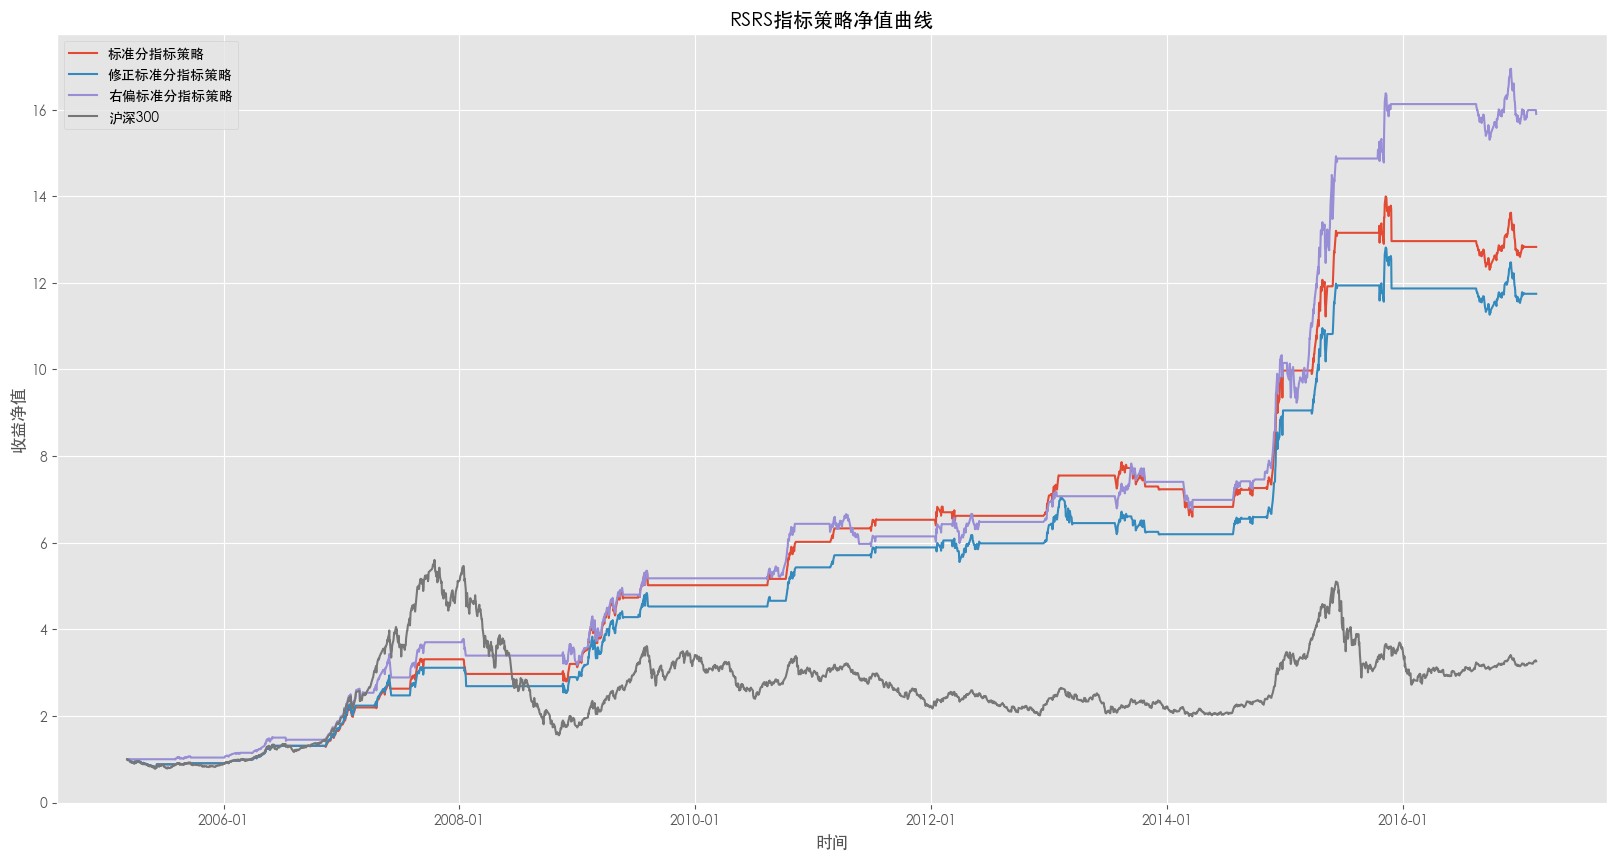

,标准分指标策略,修正标准分策略,右偏标准分策略
年化收益率,24.55%,23.61%,26.87%
累计收益率,1182.98%,1074.76%,1490.04%
夏普比率,1.562801,1.466113,1.546428
最大回撤,-20.66%,-20.66%,-16.04%
持仓总天数,844.0,901.0,1028.0
交易次数,30,28,25
平均持仓天数,28.133333,32.178571,41.12
获利天数,497,527,611
亏损天数,347,374,417
胜率(按天),58.89%,58.49%,59.44%


In [23]:
# 价格过滤
def RSRS_PriceOptimize(data):
    df1 = data.copy()
    # 标准分 / 修正标准分：N=18, M=600
    # 右偏标准分：N=16, M=300
    df_z = Cal_RSRS_Zscore(data, 18, 600)   # 含 RSRS, RSRS_Z, r2
    df_r = Cal_RSRS_Revise(data, 18, 600)   # 含 RSRS_R
    df_p = Cal_RSRS_Positive(data, 16, 300) # 含 RSRS_P

    # 取三个df都有值的共同日期（自然从2005-03-09左右开始）
    common_idx = df_z.index.intersection(df_r.index).intersection(df_p.index)

    df1['ma20'] = df1['close'].rolling(20).mean()
    df1['price_filter'] = df1['ma20'] > df1['ma20'].shift(2)

    

    df = pd.DataFrame(index=common_idx)
    df['close'] = data.loc[common_idx, 'close']
    df['high']  = data.loc[common_idx, 'high']
    df['low']   = data.loc[common_idx, 'low']
    df['RSRS']  = df_z.loc[common_idx, 'RSRS']
    df['RSRS_Z']= df_z.loc[common_idx, 'RSRS_Z']
    df['RSRS_R']= df_r.loc[common_idx, 'RSRS_R']
    df['RSRS_P']= df_p.loc[common_idx, 'RSRS_P']


    #价格过滤信号
    df['price_signal'] = df1.loc[common_idx,'price_filter']

    df = df.dropna(subset=['RSRS_Z'])  # 自动去掉前M-1天
    print(f'回测起始日：{min(df.index)}')
    

    z_signal = [0]*len(df)
    for i in range(len(df)):
        if (df['RSRS_Z'].iloc[i] > 0.7) & (df['price_signal'].iloc[i]==1):
            z_signal[i] = 1
        elif df['RSRS_Z'].iloc[i] < -0.7:
            z_signal[i] = 0
        else:
            z_signal[i] = z_signal[i-1]
    df['z_signal'] = z_signal
    df['z_signal'] = df['z_signal'].shift(1).fillna(0)

    r_signal = [0]*len(df)
    for i in range(len(df)):
        if (df['RSRS_R'].iloc[i] > 0.7) & (df['price_signal'].iloc[i]==1):
            r_signal[i] = 1
        elif df['RSRS_R'].iloc[i] < -0.7:
            r_signal[i] = 0
        else:
            r_signal[i] = r_signal[i-1]
    df['r_signal'] = r_signal
    df['r_signal'] = df['r_signal'].shift(1).fillna(0)

    p_signal = [0]*len(df)
    for i in range(len(df)):
        if (df['RSRS_P'].iloc[i] > 0.7) & (df['price_signal'].iloc[i]==1):
            p_signal[i] = 1
        elif df['RSRS_P'].iloc[i] < -0.7:
            p_signal[i] = 0
        else:
            p_signal[i] = p_signal[i-1]
    df['p_signal'] = p_signal
    df['p_signal'] = df['p_signal'].shift(1).fillna(0)

    df['ret'] = df['close'].pct_change().fillna(0)
    
    df['Z_CUM'] = (1+df['ret']*df['z_signal']).cumprod()
    df['R_CUM'] = (df['ret']*df['r_signal']+1).cumprod()
    df['P_CUM'] = (1+df['ret']*df['p_signal']).cumprod()
    
    benchmark = (df['ret']+1).cumprod()

    fig = plt.figure(figsize = (20,10))
    ax = fig.add_subplot(111)
    ax.plot(df['Z_CUM'],label='标准分指标策略')
    ax.plot(df['R_CUM'],label='修正标准分指标策略')
    ax.plot(df['P_CUM'],label='右偏标准分指标策略')
    ax.plot(benchmark,label='沪深300')

    ax.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))
    ax.legend(loc = 'best')
    ax.set_xlabel('时间')
    ax.set_ylabel('收益净值')
    ax.set_title('RSRS指标策略净值曲线')
    plt.show()
    
    display(HTML(summary2(df).to_html()))

        
RSRS_PriceOptimize(df)        

## 可见无论年化收益率还是最大回撤、盈亏比，价格过滤后都表现的更好，从曲线上看，都能一定程度上规避长熊中的抄底陷阱。

# 下面使用交易量指标过滤
## 1.计算 RSRS 标准分指标买卖信号。
## 2. 如果指标发出买入信号，同时满足前10 日交易量与修正标准分之间的相关性为正，则买入。
## 3. 如果指标发出卖出信号，则卖出手中持股。

回测起始日：2005-03-08 00:00:00


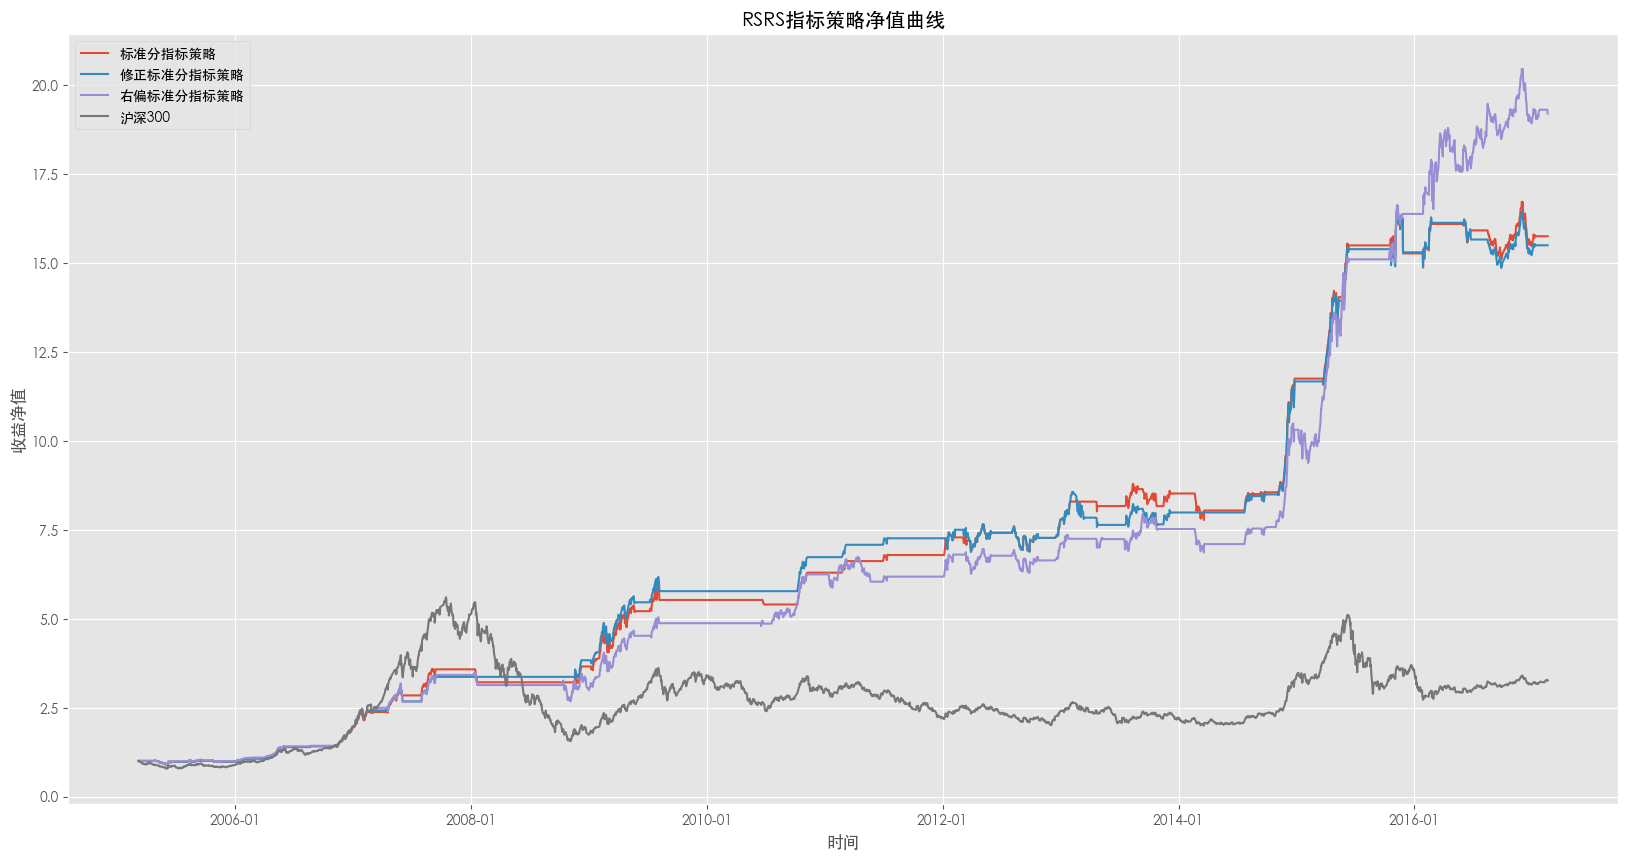

,标准分指标策略,修正标准分策略,右偏标准分策略
年化收益率,26.76%,26.58%,28.94%
累计收益率,1474.47%,1449.03%,1819.17%
夏普比率,1.652303,1.633297,1.478606
最大回撤,-13.17%,-15.76%,-23.37%
持仓总天数,953.0,960.0,1354.0
交易次数,37,32,30
平均持仓天数,25.756757,30.0,45.133333
获利天数,554,559,781
亏损天数,399,401,573
胜率(按天),58.13%,58.23%,57.68%


In [25]:
# 成交量过滤
def RSRS_VolumeOptimize(data):

    # 标准分 / 修正标准分：N=18, M=600
    # 右偏标准分：N=16, M=300
    df_z = Cal_RSRS_Zscore(data, 18, 600)   # 含 RSRS, RSRS_Z, r2
    df_r = Cal_RSRS_Revise(data, 18, 600)   # 含 RSRS_R
    df_p = Cal_RSRS_Positive(data, 16, 300) # 含 RSRS_P

    # 取三个df都有值的共同日期（自然从2005-03-09左右开始）
    common_idx = df_z.index.intersection(df_r.index).intersection(df_p.index)

    

    df = pd.DataFrame(index=common_idx)
    df['close'] = data.loc[common_idx, 'close']
    df['high']  = data.loc[common_idx, 'high']
    df['low']   = data.loc[common_idx, 'low']
    df['volume'] = data.loc[common_idx,'volume']
    df['RSRS']  = df_z.loc[common_idx, 'RSRS']
    df['RSRS_Z']= df_z.loc[common_idx, 'RSRS_Z']
    df['RSRS_R']= df_r.loc[common_idx, 'RSRS_R']
    df['RSRS_P']= df_p.loc[common_idx, 'RSRS_P']

    vol_corr = df['volume'].rolling(10).corr(df['RSRS_R'])
    df['vol_filter'] = vol_corr > 0 

    df = df.dropna(subset=['RSRS_Z'])  # 自动去掉前M-1天
    print(f'回测起始日：{min(df.index)}')
    

    z_signal = [0]*len(df)
    for i in range(len(df)):
        if (df['RSRS_Z'].iloc[i] > 0.7) & (df['vol_filter'].iloc[i]==1):
            z_signal[i] = 1
        elif df['RSRS_Z'].iloc[i] < -0.7:
            z_signal[i] = 0
        else:
            z_signal[i] = z_signal[i-1]
    df['z_signal'] = z_signal
    df['z_signal'] = df['z_signal'].shift(1).fillna(0)

    r_signal = [0]*len(df)
    for i in range(len(df)):
        if (df['RSRS_R'].iloc[i] > 0.7) & (df['vol_filter'].iloc[i]==1):
            r_signal[i] = 1
        elif df['RSRS_R'].iloc[i] < -0.7:
            r_signal[i] = 0
        else:
            r_signal[i] = r_signal[i-1]
    df['r_signal'] = r_signal
    df['r_signal'] = df['r_signal'].shift(1).fillna(0)

    p_signal = [0]*len(df)
    for i in range(len(df)):
        if (df['RSRS_P'].iloc[i] > 0.7) & (df['vol_filter'].iloc[i]==1):
            p_signal[i] = 1
        elif df['RSRS_P'].iloc[i] < -0.7:
            p_signal[i] = 0
        else:
            p_signal[i] = p_signal[i-1]
    df['p_signal'] = p_signal
    df['p_signal'] = df['p_signal'].shift(1).fillna(0)

    df['ret'] = df['close'].pct_change().fillna(0)
    
    df['Z_CUM'] = (1+df['ret']*df['z_signal']).cumprod()
    df['R_CUM'] = (df['ret']*df['r_signal']+1).cumprod()
    df['P_CUM'] = (1+df['ret']*df['p_signal']).cumprod()
    
    benchmark = (df['ret']+1).cumprod()

    fig = plt.figure(figsize = (20,10))
    ax = fig.add_subplot(111)
    ax.plot(df['Z_CUM'],label='标准分指标策略')
    ax.plot(df['R_CUM'],label='修正标准分指标策略')
    ax.plot(df['P_CUM'],label='右偏标准分指标策略')
    ax.plot(benchmark,label='沪深300')

    ax.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m'))
    ax.legend(loc = 'best')
    ax.set_xlabel('时间')
    ax.set_ylabel('收益净值')
    ax.set_title('RSRS指标策略净值曲线')
    plt.show()
    
    display(HTML(summary2(df).to_html()))

        
RSRS_VolumeOptimize(df)        